<a href="https://colab.research.google.com/github/ravsar/shap_turbofan/blob/main/Copy_of_SHAP_turbofan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import necessary modules

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats as stats

# Download NASA Turbo Fan Jet Engine data and unzip

In [2]:
# Mirror link'den veri alinip local colab drive yuklenir
# !wget https://data.nasa.gov/download/ff5v-kuh6/application%2Fzip
!wget https://phm-datasets.s3.amazonaws.com/NASA/6.+Turbofan+Engine+Degradation+Simulation+Data+Set.zip
# local drive linkindeki dosya unzip edilir, dosyalar icin yukardaki resme bakabilirsiniz
# !unzip application%2Fzip
!unzip '6.+Turbofan+Engine+Degradation+Simulation+Data+Set'
!unzip '6. Turbofan Engine Degradation Simulation Data Set/CMAPSSData.zip'

--2026-01-16 13:25:24--  https://phm-datasets.s3.amazonaws.com/NASA/6.+Turbofan+Engine+Degradation+Simulation+Data+Set.zip
Resolving phm-datasets.s3.amazonaws.com (phm-datasets.s3.amazonaws.com)... 3.5.28.70, 52.217.74.164, 3.5.22.9, ...
Connecting to phm-datasets.s3.amazonaws.com (phm-datasets.s3.amazonaws.com)|3.5.28.70|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 12429152 (12M) [application/zip]
Saving to: ‘6.+Turbofan+Engine+Degradation+Simulation+Data+Set.zip’

6.+Turbofan+Engine+ 100%[===================>]  11.85M  46.3MB/s    in 0.3s    

2026-01-16 13:25:25 (46.3 MB/s) - ‘6.+Turbofan+Engine+Degradation+Simulation+Data+Set.zip’ saved [12429152/12429152]

Archive:  6.+Turbofan+Engine+Degradation+Simulation+Data+Set.zip
   creating: 6. Turbofan Engine Degradation Simulation Data Set/
  inflating: 6. Turbofan Engine Degradation Simulation Data Set/CMAPSSData.zip  
Archive:  6. Turbofan Engine Degradation Simulation Data Set/CMAPSSData.zip
  inflating: D

# Data Preprocess

## Read train, test, and RUL (Remaining Useful Life) data files

In [3]:
df_train =  pd.read_csv("/content/train_FD002.txt",  parse_dates=False,header=None, delimiter=" ")
# check the sensors below and transform the exponential decreasing ones to exp. inreasing ones
df_test =  pd.read_csv("/content/test_FD002.txt",  parse_dates=False,header=None, delimiter=" ")
df_rul =  pd.read_csv("/content/RUL_FD002.txt",  parse_dates=False,header=None, delimiter=" ")


In [4]:
# check if the files are read properly
df_train

,0,1,2,3,4,5,6,7,8,9,...,18,19,20,21,22,23,24,25,26,27
0,1,1,34.9983,0.8400,100.0,449.44,555.32,1358.61,1137.23,5.48,...,8048.56,9.3461,0.02,334,2223,100.00,14.73,8.8071,NaN,NaN
1,1,2,41.9982,0.8408,100.0,445.00,549.90,1353.22,1125.78,3.91,...,8072.30,9.3774,0.02,330,2212,100.00,10.41,6.2665,NaN,NaN
2,1,3,24.9988,0.6218,60.0,462.54,537.31,1256.76,1047.45,7.05,...,7864.87,10.8941,0.02,309,1915,84.93,14.08,8.6723,NaN,NaN
3,1,4,42.0077,0.8416,100.0,445.00,549.51,1354.03,1126.38,3.91,...,8068.66,9.3528,0.02,329,2212,100.00,10.59,6.4701,NaN,NaN
4,1,5,25.0005,0.6203,60.0,462.54,537.07,1257.71,1047.93,7.05,...,7861.23,10.8963,0.02,309,1915,84.93,14.13,8.5286,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53754,260,312,20.0037,0.7000,100.0,491.19,608.79,1495.60,1269.51,9.35,...,8169.64,9.3035,0.03,369,2324,100.00,24.36,14.5189,NaN,NaN
53755,260,313,10.0022,0.2510,100.0,489.05,605.81,1514.32,1324.12,10.52,...,8245.36,8.7586,0.03,374,2319,100.00,28.10,16.9454,NaN,NaN
53756,260,314,25.0041,0.6200,60.0,462.54,537.48,1276.24,1057.92,7.05,...,7971.25,11.0657,0.02,310,1915,84.93,14.19,8.5503,NaN,NaN
53757,260,315,25.0033,0.6220,60.0,462.54,537.84,1272.95,1066.30,7.05,...,7972.47,11.0537,0.02,311,1915,84.93,14.05,8.3729,NaN,NaN


In [5]:
df_test

,0,1,2,3,4,5,6,7,8,9,...,18,19,20,21,22,23,24,25,26,27
0,1,1,9.9987,0.2502,100.0,489.05,605.03,1497.17,1304.99,10.52,...,8114.10,8.6476,0.03,369,2319,100.00,28.42,17.1551,NaN,NaN
1,1,2,20.0026,0.7000,100.0,491.19,607.82,1481.20,1246.11,9.35,...,8053.06,9.2405,0.02,364,2324,100.00,24.29,14.8039,NaN,NaN
2,1,3,35.0045,0.8400,100.0,449.44,556.00,1359.08,1128.36,5.48,...,8053.04,9.3472,0.02,333,2223,100.00,14.98,8.9125,NaN,NaN
3,1,4,42.0066,0.8410,100.0,445.00,550.17,1349.69,1127.89,3.91,...,8066.90,9.3961,0.02,332,2212,100.00,10.35,6.4181,NaN,NaN
4,1,5,24.9985,0.6213,60.0,462.54,536.72,1253.18,1050.69,7.05,...,7865.66,10.8682,0.02,305,1915,84.93,14.31,8.5740,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33986,259,119,35.0015,0.8403,100.0,449.44,555.56,1366.01,1129.47,5.48,...,8088.36,9.3215,0.02,334,2223,100.00,14.94,8.9065,NaN,NaN
33987,259,120,42.0066,0.8405,100.0,445.00,549.42,1351.13,1123.86,3.91,...,8108.48,9.3542,0.02,332,2212,100.00,10.57,6.4075,NaN,NaN
33988,259,121,42.0061,0.8400,100.0,445.00,549.65,1349.14,1118.91,3.91,...,8098.77,9.3836,0.02,331,2212,100.00,10.57,6.4805,NaN,NaN
33989,259,122,0.0024,0.0003,100.0,518.67,642.58,1589.61,1408.16,14.62,...,8161.85,8.4279,0.03,393,2388,100.00,39.08,23.3589,NaN,NaN


In [6]:
df_rul

,0,1
0,18,NaN
1,79,NaN
2,106,NaN
3,110,NaN
4,15,NaN
...,...,...
254,122,NaN
255,191,NaN
256,56,NaN
257,131,NaN


## Get sensor data

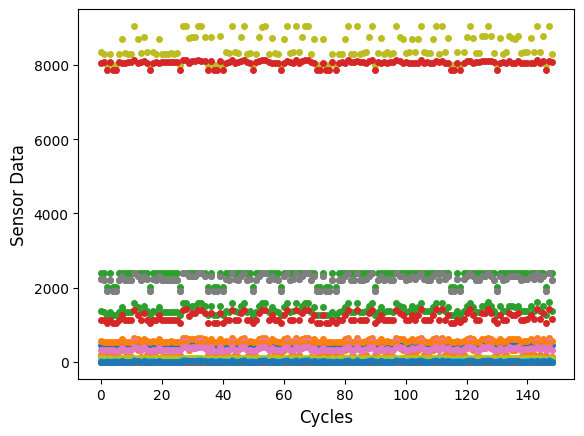

In [7]:
s_traj = df_train.iloc[:,5:-2] # FD002 Train sensor data ([...:-2] is for getting rid of the 2 NaN columns at the end)

for i in range(s_traj.shape[1]): # shape[1] is the number of columns in s_traj (selected sensors data)
  s_traj.iloc[:149,i].plot(marker='o', linestyle='none',markersize=4) # [:149] is for getting first trajectory data only
plt.xlabel('Cycles', fontsize=12)
plt.ylabel('Sensor Data', fontsize=12)
plt.tick_params(axis='both', which='major')
plt.show()

## Get reference sensor

In [8]:
ref_sensor = s_traj[5] # total temperature at fan inlet R
print(ref_sensor.unique()) # unique values in the total temperature at fan inlet

cluster = []
for cl_value in ref_sensor.unique(): # for each unique temperature at fan inlet
  cluster.append(np.where(ref_sensor == cl_value)[0]) # find the rows where each unique temperature occurs
print(cluster)

[449.44 445.   462.54 491.19 518.67 489.05]
[array([    0,    15,    17, ..., 53729, 53747, 53758]), array([    1,     3,     6, ..., 53740, 53741, 53751]), array([    2,     4,     5, ..., 53750, 53756, 53757]), array([    7,    12,    19, ..., 53737, 53746, 53754]), array([   11,    27,    28, ..., 53748, 53749, 53753]), array([   14,    30,    31, ..., 53742, 53752, 53755])]


## Arrange data to all increasing

In [9]:
# Transforming 24-25-11-16 because they have decreasing trend opposed to other useful sensors
# Combining train and test

df_all = pd.concat([df_train, df_test])

# Subtracting the values to transform the decreasing sensors into increasing ones
for t in [24,25,11,16]:
  df_all[t] = (max(df_all[t])+1) - df_all[t]

df_train=df_all.iloc[:len(df_train)]
df_test=df_all.iloc[len(df_train):]

s_traj = df_train.iloc[:,5:-2]

## Recalculate Zscore

/tmp/ipython-input-1852474801.py:22: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[-0.1674041  -1.59188977 -0.1674041  ...  0.54483874  1.96932442
  2.68156725]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  temp_sensor.iloc[c] = stats.zscore(temp_sensor.iloc[c]) # calculate zscore to normalize data and write to temp_sensor


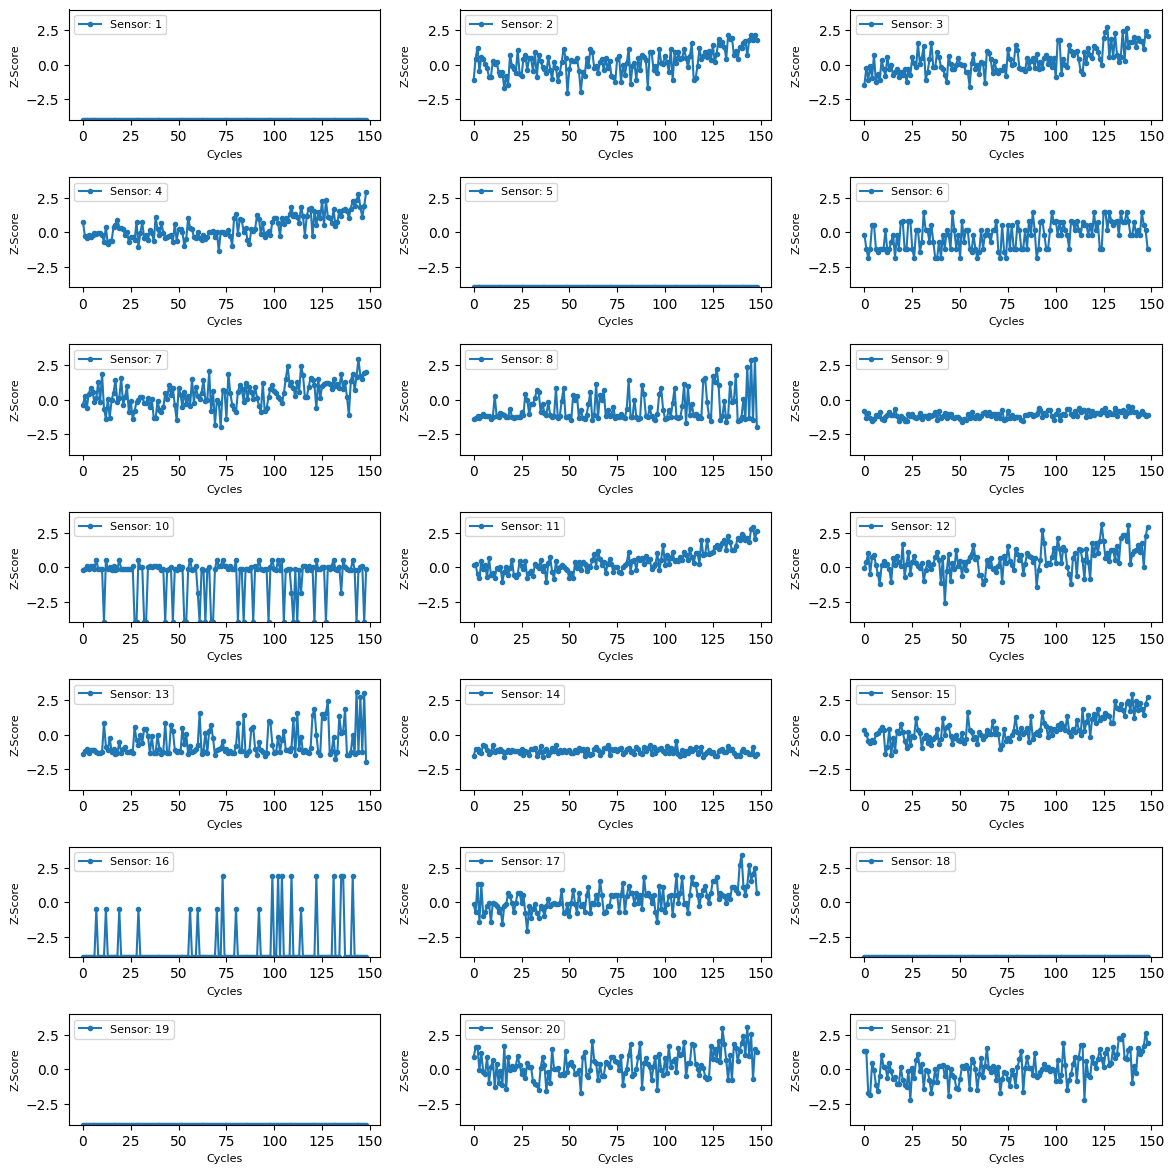

In [10]:
# Recalculate the zscore normalizations
s_traj_n = s_traj.copy() # sensor data copy

# Figure for each sensor (21 in total)
figure, axis = plt.subplots(7, 3)
figure.set_figheight(12)
figure.set_figwidth(12)
figure.tight_layout(pad=2.0)

# Scale normalized data to range [-4, 4]
def scale_to_range(column, lower=-4, upper=4):
    col_min, col_max = np.min(column), np.max(column)
    if col_min == col_max:  # Avoid division by zero for constant columns
        return np.full_like(column, lower)  # Assign all values to lower bound
    return lower + (column - col_min) / (col_max - col_min) * (upper - lower)

# Normalize sensors data wrt ref_sensor using Z-score
for s in s_traj.columns: # for each sensor
  temp_sensor = s_traj[s].copy() # copy individual sensor data
  for c in cluster: # for each row in cluster
    if abs(np.std(temp_sensor.iloc[c])) > 1e-8:
      temp_sensor.iloc[c] = stats.zscore(temp_sensor.iloc[c]) # calculate zscore to normalize data and write to temp_sensor
    else:
      temp_sensor.iloc[c] = scale_to_range(temp_sensor.iloc[c]) # calculate
  s_traj_n[s]=temp_sensor # write the normalized sensor data to new s_traj
  axis[(s-5)//3, (s-5)%3].plot(temp_sensor[:149], marker='.',label=f"Sensor: {s-4}") # first trajectory length = 149
  axis[(s-5)//3, (s-5)%3].set_xlabel('Cycles', fontsize=8)
  axis[(s-5)//3, (s-5)%3].set_ylabel('Z-Score', fontsize=8)
  axis[(s-5)//3, (s-5)%3].legend(loc=2,fontsize=8)
  # axis[(s-5)//3, (s-5)%3].set_title(f"Sensor: {s-4}", fontsize=10)
# Defining custom  'ylim' values.
custom_ylim = (-4, 4)

# Setting the values for all axes.

plt.setp(axis, ylim=custom_ylim,)
plt.show()

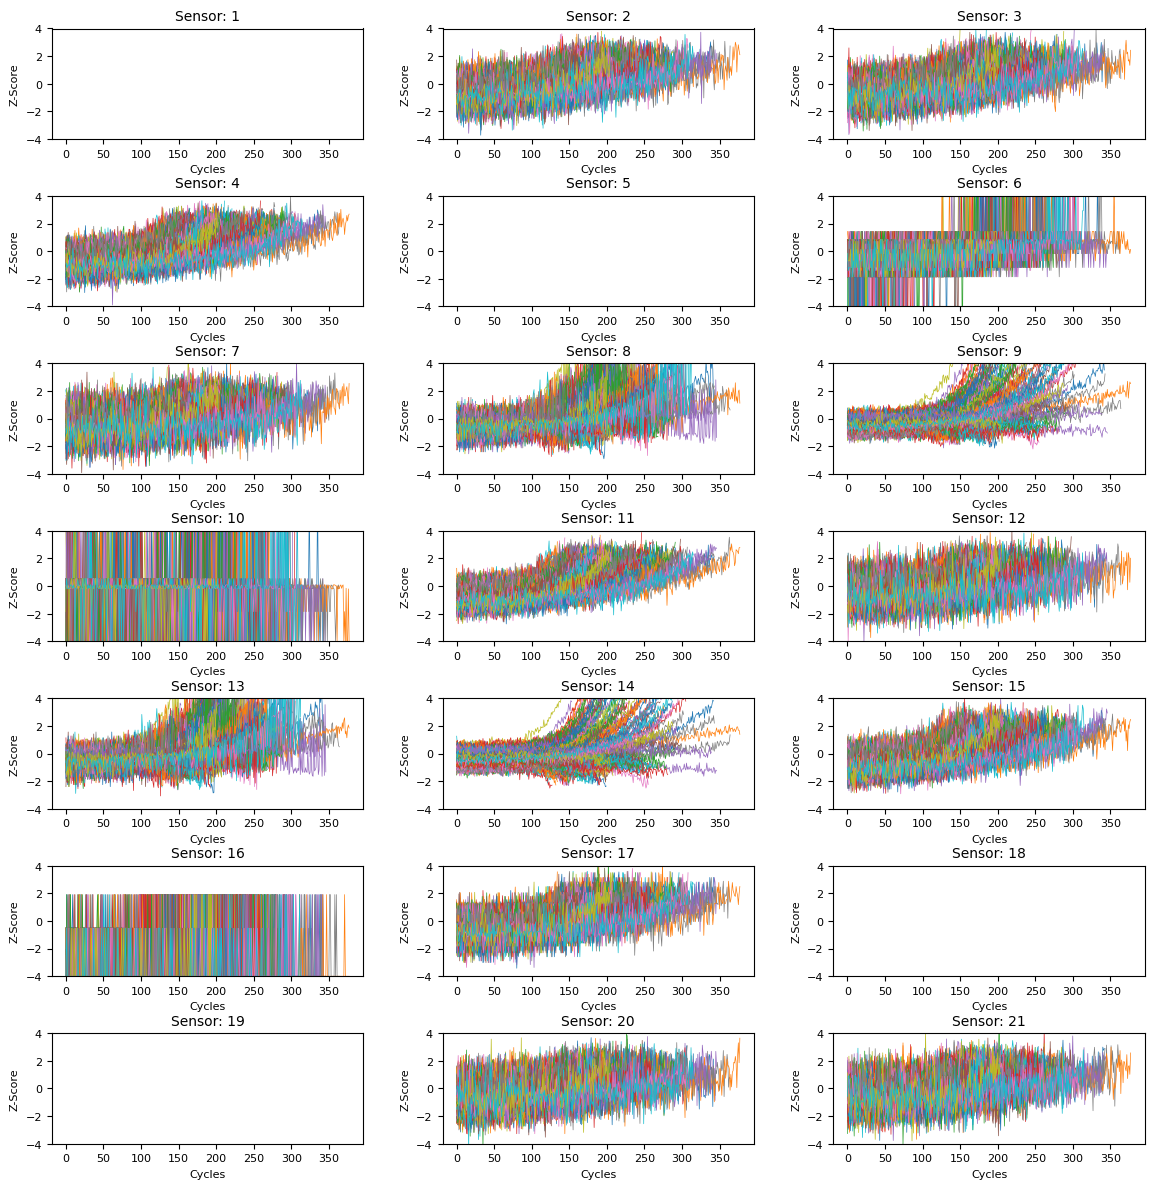

In [11]:
# Assuming df_train is already defined and contains the training data
ref_traj = df_train.iloc[:, 0]  # Assuming the first column is the reference trajectory
figure, axis = plt.subplots(7, 3)
figure.set_figheight(12)
figure.set_figwidth(12)
figure.tight_layout(pad=2.0)

# For each sensor plot the trajectory (engine) zscore normalization wrt sensor 5
for idx, s in enumerate(s_traj_n.columns): # for each sensor
    for t in ref_traj.unique(): # for each trajectory (engine)
        traj_cluster = np.where(ref_traj == t)[0] # operation cycles of the individual trajectory
        axis[idx // 3, idx % 3].plot(s_traj_n.iloc[traj_cluster, idx].tolist(), linewidth=0.5) # plot the sensor zscore data of the trajectory's cycles
        axis[idx // 3, idx % 3].set_title(f"Sensor: {s-4}", fontsize=10)
        axis[idx // 3, idx % 3].set_xlabel('Cycles', fontsize=8)
        axis[idx // 3, idx % 3].set_ylabel('Z-Score', fontsize=8)
        axis[idx // 3, idx % 3].tick_params(axis='both', which='major', labelsize=8)

# Defining custom 'ylim' values.
custom_ylim = (-4, 4)
plt.setp(axis, ylim=custom_ylim)
plt.show()



# Health Index

In [ ]:
# Health Index (HI) Creation
ref_traj = df_train.iloc[:, 0]
hi=[]
for i in  range(len(s_traj_n)):
  hi.append(np.mean(s_traj_n.iloc[i,:].values))

# Power Law Curve Fit for HI
def power_law(x, a, b, c):
    return a * np.power(x, b) + c

from scipy.optimize import curve_fit

hi_curve = []
for traj in ref_traj.unique():
  hi_traj = np.where(ref_traj == traj)[0]
  popt, pcov = curve_fit(power_law, np.arange(len(hi_traj)), np.array(hi)[hi_traj])
  hi_curve.extend(power_law(np.arange(len(hi_traj)), *popt))


/tmp/ipython-input-4142890043.py:9: RuntimeWarning: divide by zero encountered in power
  return a * np.power(x, b) + c


In [12]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [13]:
hi_curve = np.loadtxt('/content/drive/MyDrive/CMAPPS/hi_curve.txt')
hi = np.loadtxt('/content/drive/MyDrive/CMAPPS/hi.txt')

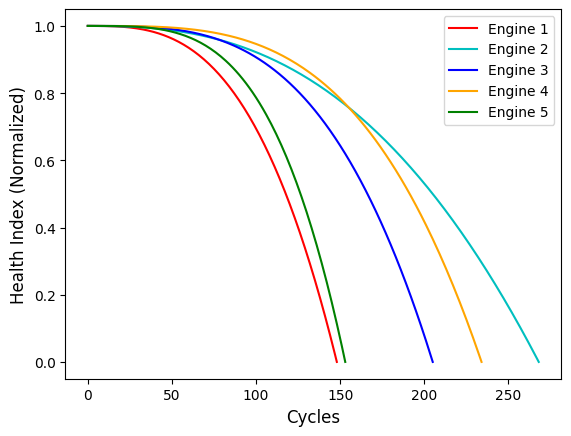

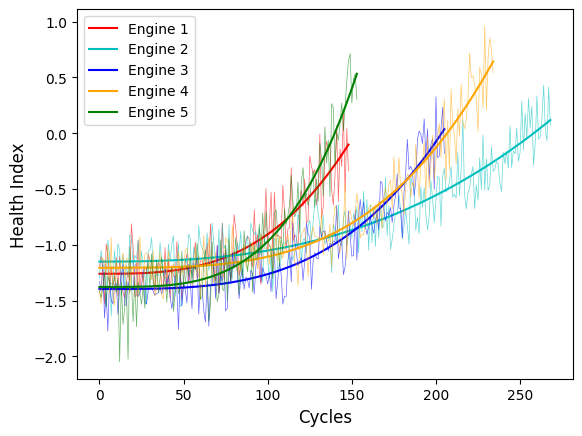

In [14]:
# Plot HI curve fit
ref_traj = df_train.iloc[:, 0]

# Scale normalized data to range [-4, 4]
def scale_to_range(column, lower=-4, upper=4):
    col_min, col_max = np.min(column), np.max(column)
    if col_min == col_max:  # Avoid division by zero for constant columns
        return np.full_like(column, lower)  # Assign all values to lower bound
    return lower + (column - col_min) / (col_max - col_min) * (upper - lower)

hi_scaled = []
his = []
hi_curves = []
for traj in ref_traj.unique():
  hi_traj = np.where(ref_traj == traj)[0]
  hi_scaled.append(scale_to_range(hi_curve[hi_traj], 1, 0))
  his.append(hi[hi_traj])
  hi_curves.append(hi_curve[hi_traj])

colors = ['r', 'c', 'b', 'orange', 'g']
for i in range(5):
  plt.plot(hi_scaled[i], colors[i], label=f"Engine {i+1}")
plt.xlabel("Cycles", fontsize=12)
plt.ylabel("Health Index (Normalized)", fontsize=12)
plt.legend()
plt.show()

for i in range(5):
  plt.plot(his[i], colors[i], linewidth=0.5, alpha=0.6)
  plt.plot(hi_curves[i], colors[i], label=f"Engine {i+1}")
plt.xlabel("Cycles", fontsize=12)
plt.ylabel("Health Index", fontsize=12)
plt.legend()
plt.show()

In [ ]:
np.savetxt('/content/drive/MyDrive/CMAPPS/hi_curve.txt', hi_curve, fmt='%.16f')
np.savetxt('/content/drive/MyDrive/CMAPPS/hi.txt', hi, fmt='%.16f')
np.savetxt('/content/drive/MyDrive/CMAPPS/s_traj_n.txt', s_traj_n, fmt='%.16f')

In [ ]:
hi_curve = np.loadtxt('/content/drive/MyDrive/CMAPPS/hi_curve.txt')
hi = np.loadtxt('/content/drive/MyDrive/CMAPPS/hi.txt')
# s_traj_n = np.loadtxt('/content/drive/MyDrive/CMAPPS/s_traj_n.txt')

# Prognostic Metrics

In [17]:
# Find nonflat sensors
nonflat = []
for sensor in s_traj_n.columns:
    if np.std(s_traj_n[sensor].values) >= 1e-8:
        nonflat.append(sensor)
print(nonflat)

[6, 7, 8, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 24, 25]


In [18]:
# Monotonicity Calculation
def calculate_monotonicity(features, engine_ids):
    monotonicity = []
    unique_engines = np.unique(engine_ids)
    for engine_id in unique_engines:
        engine_data = features[engine_ids == engine_id]
        gradients = np.gradient(engine_data, axis=0)
        mean_sign = np.mean(np.sign(gradients), axis=0)
        monotonicity.append(mean_sign)
    monotonicity = np.mean(monotonicity, axis=0)
    return monotonicity

from scipy.interpolate import interp1d

def calculate_trendability(features, engine_ids):
    unique_engines = np.unique(engine_ids)
    trendability = []

    # Normalize each engine's life cycle
    normalized_features = {}
    for engine_id in unique_engines:
        engine_data = features[engine_ids == engine_id]
        time_steps = np.linspace(0, 1, engine_data.shape[0])  # Normalize life cycle to [0, 1]

        # Interpolate each feature to a consistent scale (e.g., 100 points)
        interpolated_data = []
        for feature_idx in engine_data.columns:
            interp_func = interp1d(time_steps, engine_data[feature_idx], kind="linear", fill_value="extrapolate")
            interpolated_data.append(interp_func(np.linspace(0, 1, 100)))  # Interpolate to 100 points

        normalized_features[engine_id] = np.array(interpolated_data).T  # Shape: (100, num_features)

    # Calculate trendability for each feature
    num_features = features.shape[1]
    for feature_idx in range(num_features):
        correlations = []
        for i, id1 in enumerate(unique_engines):
            for id2 in unique_engines[i + 1:]:
                feature_1 = normalized_features[id1][:, feature_idx]
                feature_2 = normalized_features[id2][:, feature_idx]

                if np.std(feature_1) > 0 and np.std(feature_2) > 0:  # Skip constant features
                    corr = np.corrcoef(feature_1, feature_2)[0, 1]
                    correlations.append(corr)

        # Mean pairwise correlation for the current feature
        trendability.append(np.mean(correlations) if len(correlations) > 0 else np.nan)

    return trendability

# Prognosability Calculation
def calculate_prognosability(features, engine_ids):
    unique_engines = np.unique(engine_ids)
    std_devs = []
    for engine_id in unique_engines:
        engine_data = features[engine_ids == engine_id]
        std_devs.append(engine_data.std(axis=0))
    overall_std = features.std(axis=0)
    prognosability = 1 - (np.mean(std_devs, axis=0) / overall_std)
    return prognosability

# Run metrics calculation
# nonflat sensors
s_nonflat = s_traj_n[[6, 7, 8, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 24, 25]]
monotonicity = calculate_monotonicity(s_nonflat, df_train[0].values)
trendability = calculate_trendability(s_nonflat, df_train[0].values)
prognosability = calculate_prognosability(s_nonflat, df_train[0].values)

# Results
results = pd.DataFrame({
    'Feature': [f'Sensor {i-4}' for i in [6, 7, 8, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 24, 25]],
    'Monotonicity': monotonicity,
    'Trendability': trendability,
    'Prognosability': prognosability
})

print(results)

      Feature  Monotonicity  Trendability  Prognosability
6    Sensor 2      0.015975      0.568668        0.044742
7    Sensor 3      0.024390      0.552865        0.043789
8    Sensor 4      0.033690      0.758983        0.070559
10   Sensor 6      0.008511      0.202723        0.037514
11   Sensor 7      0.016384      0.384209        0.046532
12   Sensor 8      0.017998      0.335963        0.121982
13   Sensor 9      0.037245      0.180579        0.370532
14  Sensor 10     -0.004397      0.003749        0.026671
15  Sensor 11      0.041925      0.836060        0.090406
16  Sensor 12      0.010194      0.425724        0.056358
17  Sensor 13      0.021521      0.334457        0.122341
18  Sensor 14      0.026819      0.051702        0.405889
19  Sensor 15      0.033843      0.737355        0.077104
20  Sensor 16     -0.000882      0.009618        0.001390
21  Sensor 17      0.021699      0.597139        0.045280
24  Sensor 20      0.013490      0.348618        0.031502
25  Sensor 21 

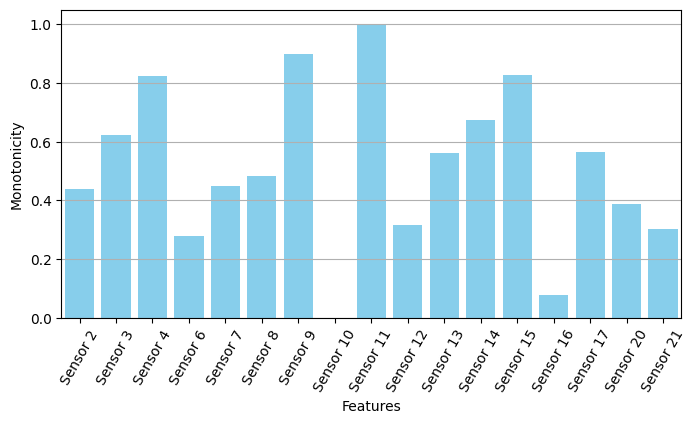

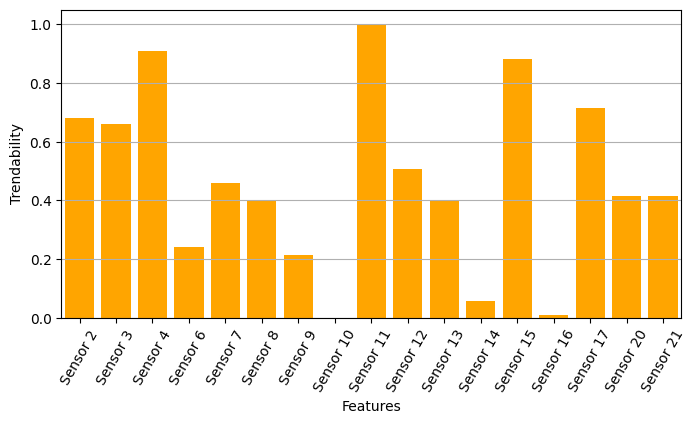

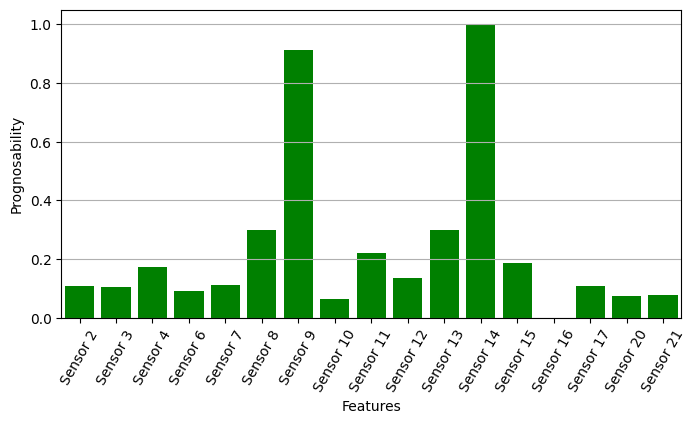

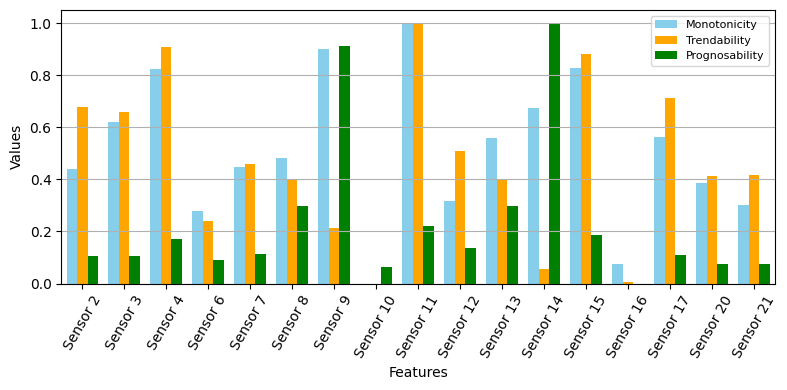

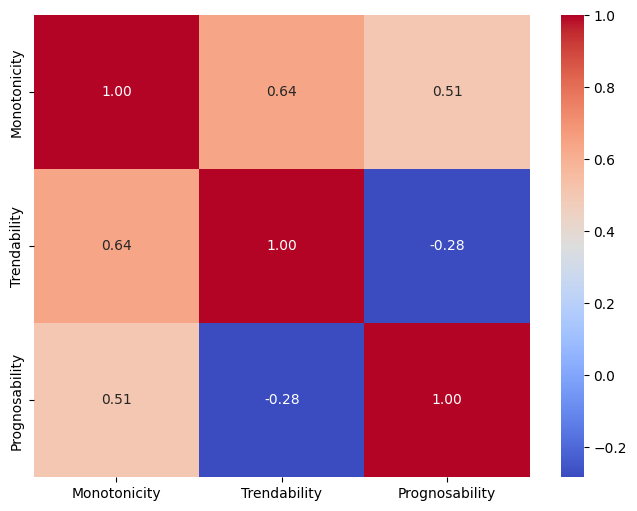

In [19]:
# Visualize prognostic metrics
import matplotlib.pyplot as plt

results = pd.read_csv('/content/drive/MyDrive/CMAPPS/prognostic_metrics.txt')
mono = scale_to_range(results['Monotonicity'],0,1)
trend = scale_to_range(results['Trendability'],0,1)
prog = scale_to_range(results['Prognosability'],0,1)

# Visualize Monotonicity
plt.figure(figsize=(8, 4))
plt.bar(results['Feature'], mono, color='skyblue')
# plt.title('Monotonicity of Features')
plt.xlabel('Features', fontsize=10)
plt.ylabel('Monotonicity', fontsize=10)
plt.xticks(rotation=60)
plt.xlim(-0.5,16.5)
plt.grid(axis='y')
plt.show()
# Visualize Trendability
plt.figure(figsize=(8,4))
plt.bar(results['Feature'], trend, color='orange')
# plt.title('Trendability of Features')
plt.xlabel('Features', fontsize=10)
plt.ylabel('Trendability', fontsize=10)
plt.xticks(rotation=60)
plt.xlim(-0.5,16.5)
plt.grid(axis='y')
plt.show()
# Visualize Prognosability
plt.figure(figsize=(8, 4))
plt.bar(results['Feature'], prog, color='green')
# plt.title('Prognosability of Features')
plt.xlabel('Features', fontsize=10)
plt.ylabel('Prognosability', fontsize=10)
plt.xticks(rotation=60)
plt.grid(axis='y')
plt.xlim(-0.5,16.5)
plt.show()
import numpy as np

# Data preparation for grouped bar chart
x = np.arange(len(results['Feature']))  # Feature indices
width = 0.25  # Bar width

# Plot grouped bars
plt.figure(figsize=(8,4))
plt.bar(x - width, mono, width, label='Monotonicity', color='skyblue')
plt.bar(x, trend, width, label='Trendability', color='orange')
plt.bar(x + width, prog, width, label='Prognosability', color='green')

# Add labels and title
# plt.title('Comparison of Monotonicity, Trendability, and Prognosability')
plt.xlabel('Features')
plt.ylabel('Values')
plt.xticks(x, results['Feature'], rotation=60)
plt.legend(fontsize=8)
plt.grid(axis='y')
plt.xlim(-0.5,16.5)
plt.tight_layout()
plt.show()
import seaborn as sns

# Compute correlations between metrics
results['mono'] = mono
results['trend'] = trend
results['prog'] = prog
correlation_matrix = results[['Monotonicity', 'Trendability', 'Prognosability']].corr()

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
# plt.title('Correlation Heatmap of Metrics')
plt.show()

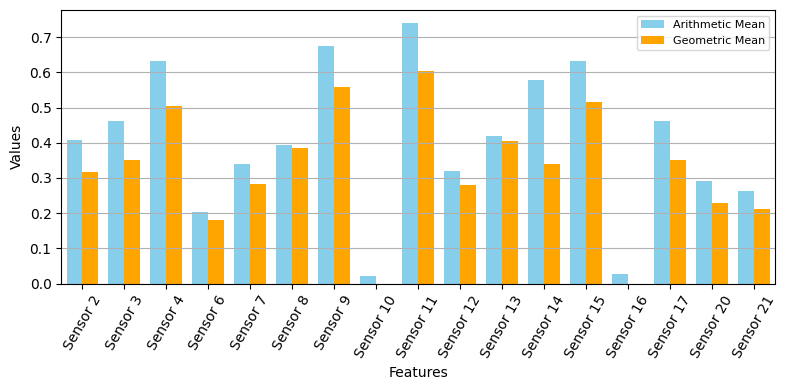

In [20]:
mono = scale_to_range(results['Monotonicity'],0,1)
trend = scale_to_range(results['Trendability'],0,1)
prog = scale_to_range(results['Prognosability'],0,1)
prognostic_metric_l = (mono+trend+prog)/3
prognostic_metric_g = (mono*trend*prog)**(1/3)
results['Prognostic Metric (L)'] = prognostic_metric_l
results['Prognostic Metric (G)'] = prognostic_metric_g

# plt.bar(results['Feature'], results['Prognostic Metric (L)'], label='Prognostic Metric (L)')
# plt.bar(results['Feature'], results['Prognostic Metric (G)'], label='Prognostic Metric (G)')
# plt.xlabel('Features')
# plt.ylabel('Values')
# plt.xticks(rotation=90)
# plt.legend()

# Data preparation for grouped bar chart
x = np.arange(len(results['Feature']))  # Feature indices
width = 0.375  # Bar width

# Plot grouped bars
plt.figure(figsize=(8,4))
plt.bar(x - width/2, results['Prognostic Metric (L)'], width, label='Arithmetic Mean', color='skyblue')
plt.bar(x + width/2, results['Prognostic Metric (G)'], width, label='Geometric Mean', color='orange')

# Add labels and title
plt.xlabel('Features')
plt.ylabel('Values')
plt.xticks(x, results['Feature'], rotation=60)
plt.legend(fontsize=8)
plt.grid(axis='y')
plt.xlim(-0.5,16.5)
plt.tight_layout()
plt.show()

In [ ]:
results.to_csv('/content/drive/MyDrive/CMAPPS/prognostic_metrics.txt', index=False)

# RandomForest

In [21]:
# Train-Test split based on Engine IDs
from sklearn.model_selection import train_test_split
X = df_train.iloc[:,5:-2]
y = pd.Series(hi_curve)

# 1. Get all unique engine IDs (there should be 260 of them)
unique_engine_ids = df_train[0].unique()

# 2. Split the list of unique IDs (this splits the 260 engines 80/20)
train_engine_ids, test_engine_ids = train_test_split(unique_engine_ids,
                                                     test_size=0.2,
                                                     random_state=42)

# 3. Create boolean masks to select all rows belonging to these engines
train_mask = df_train[0].isin(train_engine_ids)
test_mask = df_train[0].isin(test_engine_ids)

# 4. Apply the masks to your features (X) and target (y)
X_train1 = X[train_mask]
y_train1 = y[train_mask]
X_test1 = X[test_mask]
y_test1 = y[test_mask]

# 5. Print the test engine IDs
print(f"Total engines: {len(unique_engine_ids)}")
print(f"Training engines: {len(train_engine_ids)}")
print(f"Test engines: {len(test_engine_ids)}")
print(f"Test Engine ID List: {test_engine_ids}") # This is the list for your response
print("---")
print(f"X_train shape: {X_train1.shape}, y_train shape: {y_train1.shape}")
print(f"X_test shape: {X_test1.shape}, y_test shape: {y_test1.shape}")

Total engines: 260
Training engines: 208
Test engines: 52
Test Engine ID List: [ 31 182 224 186 212 259 174 143  10 178  25 214  78 205 191 207 243   7
 221 105 115 120  20 202 180  47  76  46 155  16 237 229 145  34 197 102
 213  11 114  97  93 151  26 159  19 238 140  69  98 168  91 206]
---
X_train shape: (43464, 21), y_train shape: (43464,)
X_test shape: (10295, 21), y_test shape: (10295,)


In [22]:
from sklearn.ensemble import RandomForestRegressor
# Train the Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(X_train1, y_train1)

RandomForestRegressor(max_depth=10, random_state=42)

In [23]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Assuming model is your trained regression model
y_pred = rf_model.predict(X_test1)

mae = mean_absolute_error(y_test1, y_pred)
mse = mean_squared_error(y_test1, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test1, y_pred)

print(f"MAE: {mae:.3f}")
print(f"MSE: {mse:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R² Score: {r2:.3f}")


MAE: 0.108
MSE: 0.019
RMSE: 0.136
R² Score: 0.920


In [24]:
# --- 5. Bootstrap Confidence Intervals (per Reviewer #2) ---
print("\nRunning bootstrap analysis 'over engines'...")
n_bootstraps = 1000
bootstrapped_metrics = {'mae': [], 'mse': [], 'rmse': [], 'r2': []}

# Ensure y_test and y_pred are pandas Series with the same index
# for easy .loc[boot_indices] selection
y_test_series = pd.Series(y_test1, index=X_test1.index)
y_pred_series = pd.Series(y_pred, index=X_test1.index)
engine_id_col = df_train[0]
engine_ids_test_series = pd.Series(engine_id_col[test_mask], index=X_test1.index)

for i in range(n_bootstraps):
    # 1. Resample *engine IDs* with replacement
    #    We use 'test_engine_ids', which is your list of 52 unique IDs
    boot_engine_ids = np.random.choice(
        test_engine_ids,
        size=len(test_engine_ids),
        replace=True
    )

    # 2. Get all row indices for the resampled engines
    #    We use 'engine_ids_test_series' (the column of IDs
    #    for all test rows) to find the matching rows.
    boot_indices = []
    for engine_id in boot_engine_ids:
        indices_for_id = engine_ids_test_series[engine_ids_test_series == engine_id].index
        boot_indices.extend(indices_for_id)

    # 3. Select the data for this bootstrap iteration
    y_boot_true = y_test_series.loc[boot_indices]
    y_boot_pred = y_pred_series.loc[boot_indices]

    # 4. Calculate and store metrics
    boot_mae = mean_absolute_error(y_boot_true, y_boot_pred)
    boot_mse = mean_squared_error(y_boot_true, y_boot_pred)
    boot_rmse = boot_mse ** 0.5
    boot_r2 = r2_score(y_boot_true, y_boot_pred)

    bootstrapped_metrics['mae'].append(boot_mae)
    bootstrapped_metrics['mse'].append(boot_mse)
    bootstrapped_metrics['rmse'].append(boot_rmse)
    bootstrapped_metrics['r2'].append(boot_r2)

# --- 5. Calculate 95% Confidence Intervals ---
print("\nBootstrap 95% Confidence Intervals:")
for metric_name, values in bootstrapped_metrics.items():
    lower_bound = np.percentile(values, 2.5)
    upper_bound = np.percentile(values, 97.5)
    print(f"{metric_name.upper()}: [{lower_bound:.3f} - {upper_bound:.3f}]")


Running bootstrap analysis 'over engines'...

Bootstrap 95% Confidence Intervals:
MAE: [0.102 - 0.113]
MSE: [0.017 - 0.020]
RMSE: [0.130 - 0.143]
R2: [0.907 - 0.931]


# SHAP for RandomForest

In [34]:
# SHAP Analysis
import shap
explainer = shap.Explainer(rf_model, X_train1)
shap_values = explainer(X_test1[:200])
# 1. Summary Plot
features = {
    "Sensor 1": "Total temperature at fan inlet (°R)",
    "Sensor 2": "Total temperature at LPC outlet (°R)",
    "Sensor 3": "Total temperature at HPC outlet (°R)",
    "Sensor 4": "Total temperature at LPT outlet (°R)",
    "Sensor 5": "Pressure at fan inlet (psia)",
    "Sensor 6": "Total pressure in bypass-duct (psia)",
    "Sensor 7": "Total pressure at HPC outlet (psia)",
    "Sensor 8": "Physical fan speed",
    "Sensor 9": "Physical core speed",
    "Sensor 10": "Engine pressure ratio",
    "Sensor 11": "Static pressure at HPC outlet (psia)",
    "Sensor 12": "Ratio of fuel flow to Ps30 (pps/psi)",
    "Sensor 13": "Corrected fan speed (rpm)",
    "Sensor 14": "Corrected core speed (rpm)",
    "Sensor 15": "Bypass ratio",
    "Sensor 16": "Burner fuel-air ratio",
    "Sensor 17": "Bleed enthalpy",
    "Sensor 18": "Demanded fan speed (rpm)",
    "Sensor 19": "Demanded corrected fan speed (rpm)",
    "Sensor 20": "HPT coolant bleed (lbm/s)",
    "Sensor 21": "LPT coolant bleed (lbm/s)"
}

In [36]:
import matplotlib.colors
import matplotlib.pyplot as plt

# --- DEFINE AND REGISTER THE SHAP COLORMAP ---
# This is the exact definition from the SHAP library
cdict = {
    "red": [
        (0.0, 0.0, 0.00784313725490196),
        (0.6, 0.7, 0.7),
        (1.0, 1.0, 1.0), # Increased red value for brighter red
    ],
    "green": [
        (0.0, 0.5450980392156862, 0.5450980392156862),
        (0.6, 0.3, 0.3),
        (1.0, 0.0, 0.0),
    ],
    "blue": [
        (0.0, 1.0, 1.0), # Increased blue value for brighter blue
        (0.6, 0.8, 0.8),
        (1.0, 0.01568627450980392, 0.01568627450980392),
    ],
}
# Create the colormap object
shap_cmap = matplotlib.colors.LinearSegmentedColormap("shap_red_blue", cdict)
# Unregister if already exists
if "shap_red_blue" in matplotlib.colormaps:
    matplotlib.colormaps.unregister("shap_red_blue")
matplotlib.colormaps.register(cmap=shap_cmap)

/tmp/ipython-input-2423084846.py:37: UserWarning: You passed a edgecolor/edgecolors ('none') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(


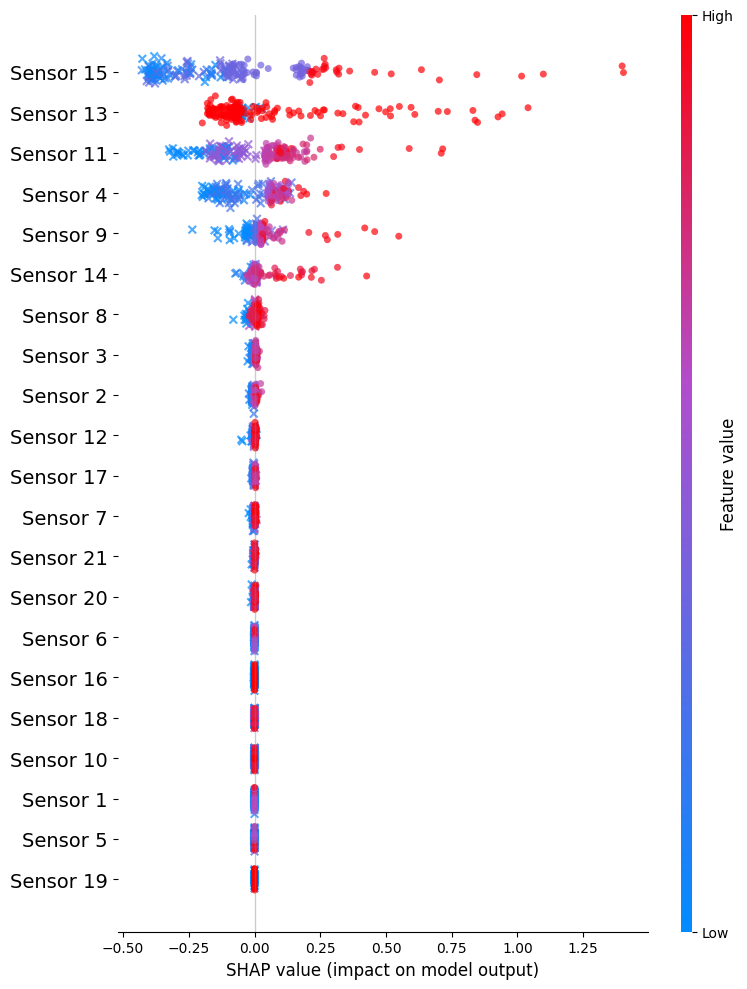

In [38]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm
from matplotlib.colors import ListedColormap

# --- 1. Data Preparation ---
X_data = X_test1[:200]
# Use the actual SHAP values (not the object) for manual plotting
shap_values_matrix = shap_values.values[:200]
feature_names_list = list(features.keys())

# --- 2. Setup Figure ---
fig, ax = plt.subplots(figsize=(8, 10))

# Calculate global feature importance for ranking (mean absolute SHAP)
mean_abs_shap = np.abs(shap_values_matrix).mean(0)
feature_order = np.argsort(mean_abs_shap)

for i, feature_idx in enumerate(feature_order):
    shaps = shap_values_matrix[:, feature_idx]
    f_values = X_data.iloc[:, feature_idx].values

    # Calculate threshold based on MEAN (consistent with dependence plots)
    threshold = f_values.mean()

    # Define masks for markers
    low_mask = (f_values <= threshold)
    high_mask = (f_values > threshold)

    # Normalise for consistent colour mapping (MIN/MAX)
    norm = plt.Normalize(f_values.min(), f_values.max())

    # Add jitter to mimic the 'beeswarm' density
    jitter = np.random.normal(0, 0.12, size=len(shaps))

    # Plot 'Low' values with 'x' (Consistent with your Dependence Plot code)
    ax.scatter(
        shaps[low_mask], i + jitter[low_mask],
        c=f_values[low_mask], cmap='shap_red_blue', norm=norm,
        marker='x', s=30, alpha=0.7, edgecolors='none'
    )

    # Plot 'High' values with 'o' (Consistent with your Dependence Plot code)
    ax.scatter(
        shaps[high_mask], i + jitter[high_mask],
        c=f_values[high_mask], cmap='shap_red_blue', norm=norm,
        marker='o', s=25, alpha=0.7, edgecolors='none'
    )

# --- 4. Aesthetics and Colorbar (Updated for Formatting) ---

# Generate the cleaned labels by removing the hyphen/dash
cleaned_labels = [feature_names_list[idx].replace('-', '').strip() for idx in feature_order]

ax.set_yticks(range(len(feature_order)))

# Use the cleaned labels and increase the fontsize to your preference (e.g., 14)
ax.set_yticklabels(cleaned_labels, fontsize=14)

ax.axvline(0, color='gray', lw=1, alpha=0.4)
ax.set_xlabel("SHAP value (impact on model output)", fontsize=12)

# Colorbar configuration
sm = plt.cm.ScalarMappable(cmap='shap_red_blue', norm=plt.Normalize(0, 1))
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, ticks=[0, 1], aspect=80, pad=0.05)
cbar.set_ticklabels(['Low', 'High'])
cbar.set_label('Feature value', fontsize=12, labelpad=-10)
cbar.outline.set_visible(False)

# Remove spines to match the original SHAP aesthetic
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

plt.tight_layout()
plt.show()

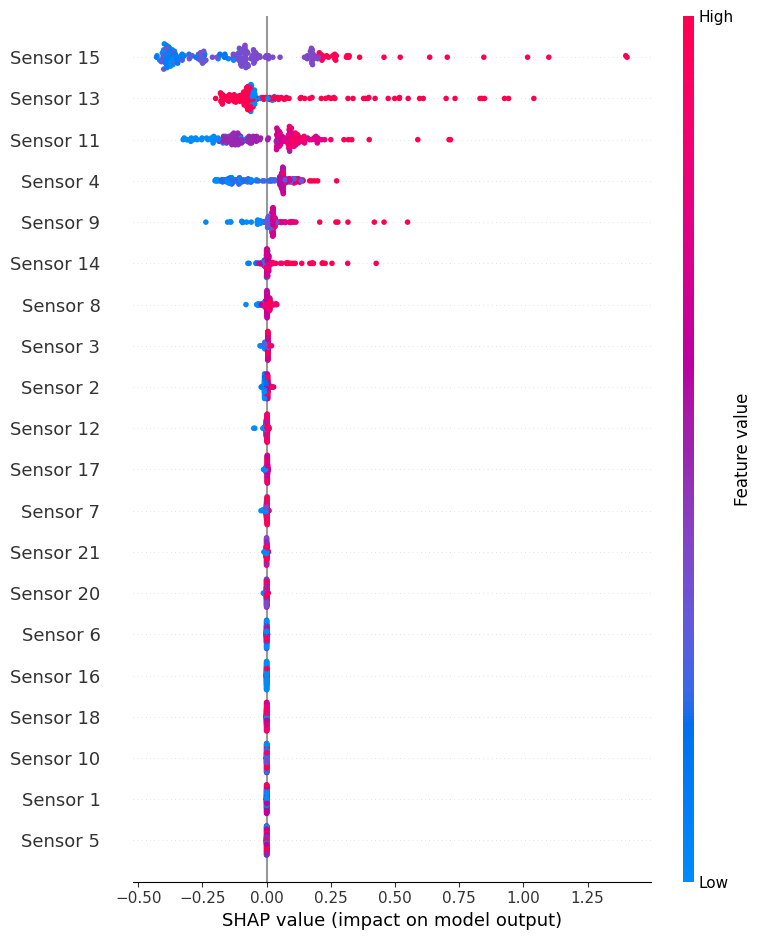

In [ ]:
# SHAP Analysis
import shap
explainer = shap.Explainer(rf_model, X_train1)
shap_values = explainer(X_test1[:200])
# 1. Summary Plot
features = {
    "Sensor 1": "Total temperature at fan inlet (°R)",
    "Sensor 2": "Total temperature at LPC outlet (°R)",
    "Sensor 3": "Total temperature at HPC outlet (°R)",
    "Sensor 4": "Total temperature at LPT outlet (°R)",
    "Sensor 5": "Pressure at fan inlet (psia)",
    "Sensor 6": "Total pressure in bypass-duct (psia)",
    "Sensor 7": "Total pressure at HPC outlet (psia)",
    "Sensor 8": "Physical fan speed",
    "Sensor 9": "Physical core speed",
    "Sensor 10": "Engine pressure ratio",
    "Sensor 11": "Static pressure at HPC outlet (psia)",
    "Sensor 12": "Ratio of fuel flow to Ps30 (pps/psi)",
    "Sensor 13": "Corrected fan speed (rpm)",
    "Sensor 14": "Corrected core speed (rpm)",
    "Sensor 15": "Bypass ratio",
    "Sensor 16": "Burner fuel-air ratio",
    "Sensor 17": "Bleed enthalpy",
    "Sensor 18": "Demanded fan speed (rpm)",
    "Sensor 19": "Demanded corrected fan speed (rpm)",
    "Sensor 20": "HPT coolant bleed (lbm/s)",
    "Sensor 21": "LPT coolant bleed (lbm/s)"
}
shap.summary_plot(shap_values, X_test1[:200], feature_names=list(features.keys()))

In [39]:
import numpy as np
import pandas as pd
from scipy.stats import spearmanr
# We use .mean() for arithmetic mean, not gmean
from numpy import mean as arithmetic_mean

# --- 1. Prepare Prognostic Scores ---
# Calculate Arithmetic Mean (This is robust to zeros)
results['Arithmetic_Mean'] = results[['Monotonicity', 'Trendability', 'Prognosability']].apply(arithmetic_mean, axis=1)

# Set 'Feature' as the index for easy lookup
prognostic_scores = results.set_index('Feature')['Arithmetic_Mean']

print("--- 1. Prognostic Scores (Arithmetic Mean) ---")
print(prognostic_scores.head())

# --- 2. Prepare SHAP Scores ---
shap_values_raw = shap_values.values

# Calculate mean absolute SHAP values for all 21 features
mean_abs_shap = np.abs(shap_values_raw).mean(axis=0)

# Manually create the 21 string names for the index
sensor_names_21 = [f'Sensor {i}' for i in range(1, 22)]

# Create the Series using the correct string names
shap_scores = pd.Series(mean_abs_shap, index=sensor_names_21)

print("\n--- 2. SHAP Scores (All 21 Sensors) ---")
print(shap_scores.head())

# --- 3. Align Both Lists to the 15 Model Features ---
# This list is from your manuscript [cite: 118-119]
model_feature_names = [
    'Sensor 2', 'Sensor 3', 'Sensor 4', 'Sensor 6',
    'Sensor 7', 'Sensor 8', 'Sensor 9', 'Sensor 11',
    'Sensor 12', 'Sensor 13', 'Sensor 14', 'Sensor 15',
    'Sensor 17', 'Sensor 20', 'Sensor 21'
]

# Filter prognostic scores to only these 15
aligned_prognostic = prognostic_scores.loc[model_feature_names]

# Filter SHAP scores to only these 15
aligned_shap = shap_scores.loc[model_feature_names]

print(f"\n--- 3. Aligned for {len(model_feature_names)} Model Features ---")
print("Prognostic:\n", aligned_prognostic)
print("\nSHAP:\n", aligned_shap)


# --- 4. Calculate Spearman Rank Correlation ---
correlation, p_value = spearmanr(aligned_prognostic, aligned_shap)

print("\n" + "="*40)
print("   SPEARMAN CORRELATION RESULTS   ")
print("="*40)
print(f"Spearman Rank Correlation (rho): {correlation:.4f}")
print(f"P-value: {p_value:.4f}")
print("\nThese are the REAL numbers for Reviewer #2.")

--- 1. Prognostic Scores (Arithmetic Mean) ---
Feature
Sensor 2    0.209795
Sensor 3    0.207015
Sensor 4    0.287744
Sensor 6    0.082916
Sensor 7    0.149042
Name: Arithmetic_Mean, dtype: float64

--- 2. SHAP Scores (All 21 Sensors) ---
Sensor 1    0.000010
Sensor 2    0.005073
Sensor 3    0.005261
Sensor 4    0.096724
Sensor 5    0.000003
dtype: float64

--- 3. Aligned for 15 Model Features ---
Prognostic:
 Feature
Sensor 2     0.209795
Sensor 3     0.207015
Sensor 4     0.287744
Sensor 6     0.082916
Sensor 7     0.149042
Sensor 8     0.158648
Sensor 9     0.196119
Sensor 11    0.322797
Sensor 12    0.164092
Sensor 13    0.159440
Sensor 14    0.161470
Sensor 15    0.282767
Sensor 17    0.221373
Sensor 20    0.131203
Sensor 21    0.130352
Name: Arithmetic_Mean, dtype: float64

SHAP:
 Sensor 2     0.005073
Sensor 3     0.005261
Sensor 4     0.096724
Sensor 6     0.000305
Sensor 7     0.002331
Sensor 8     0.009109
Sensor 9     0.042771
Sensor 11    0.132445
Sensor 12    0.003152
Sens

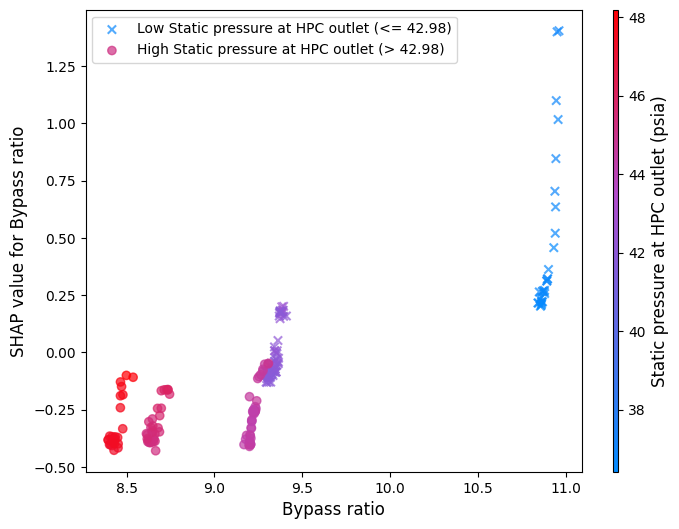

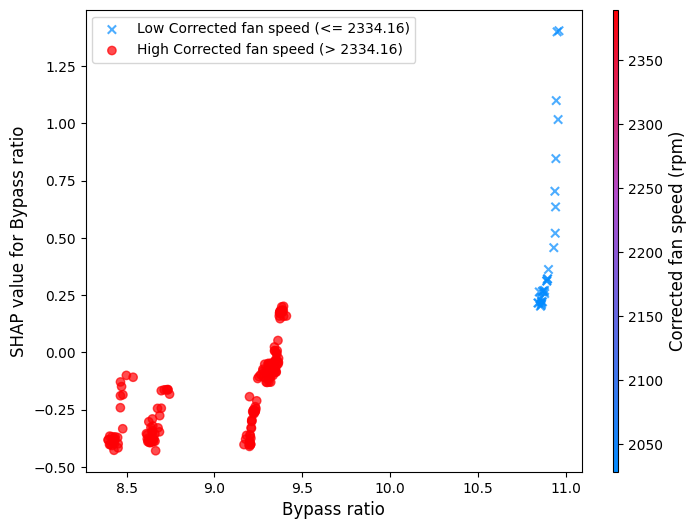

In [ ]:
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Get Your Data ---
X_data = X_test1[:200]
shap_data = shap_values.values[:200]
feature_names_list = list(features.values())

# --- 2. Generate Figure 15 (This one is probably fine, but use mean for consistency) ---
x_axis_data = X_data.iloc[:, 14]
y_axis_data = shap_data[:, 14]
interaction_data_fig15 = X_data.iloc[:, 10].astype(float)

# --- FIX: Use MEAN for threshold and MIN/MAX for norm and apply masks correctly ---
threshold_fig15 = interaction_data_fig15.mean()
low_mask_fig15 = (interaction_data_fig15 <= threshold_fig15)
high_mask_fig15 = (interaction_data_fig15 > threshold_fig15)

# Apply masks to the data before passing to scatter and convert to NumPy arrays
x_low_fig15 = x_axis_data[low_mask_fig15].values
y_low_fig15 = y_axis_data[low_mask_fig15]
c_low_fig15 = interaction_data_fig15[low_mask_fig15].values

x_high_fig15 = x_axis_data[high_mask_fig15].values
y_high_fig15 = y_axis_data[high_mask_fig15]
c_high_fig15 = interaction_data_fig15[high_mask_fig15].values


norm_fig15 = plt.Normalize(interaction_data_fig15.min(), interaction_data_fig15.max())
# --- END FIX ---

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(
    x_low_fig15, y_low_fig15,
    c=c_low_fig15,
    cmap='shap_red_blue', norm=norm_fig15, marker='x', alpha=0.7,
    label=f'Low {feature_names_list[10].split("(")[0].strip()} (<= {threshold_fig15:.2f})'
)
ax.scatter(
    x_high_fig15, y_high_fig15,
    c=c_high_fig15,
    cmap='shap_red_blue', norm=norm_fig15, marker='o', alpha=0.7,
    label=f'High {feature_names_list[10].split("(")[0].strip()} (> {threshold_fig15:.2f})'
)
ax.set_xlabel(feature_names_list[14], fontsize=12)
ax.set_ylabel(f'SHAP value for {feature_names_list[14]}', fontsize=12)
# ax.set_title('Figure 15: SHAP Dependence Plot (Accessible)', fontsize=14)
ax.legend()
sm = plt.cm.ScalarMappable(cmap='shap_red_blue', norm=norm_fig15)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, shrink=1.0, aspect=80) # Adjusted aspect for thinness, kept shrink at 1.0
cbar.set_label(feature_names_list[10], fontsize=12)
plt.show()


# --- 3. Generate Figure 16 (FINAL, CORRECTED CODE) ---
x_axis_data = X_data.iloc[:, 14]
y_axis_data = shap_data[:, 14]
interaction_data_fig16 = X_data.iloc[:, 12].astype(float) # Sensor 13

# --- FIX: Use MEAN for threshold and MIN/MAX for norm and apply masks correctly ---
threshold_fig16 = interaction_data_fig16.mean()
low_mask_fig16 = (interaction_data_fig16 <= threshold_fig16)
high_mask_fig16 = (interaction_data_fig16 > threshold_fig16)

# Apply masks to the data before passing to scatter and convert to NumPy arrays
x_low_fig16 = x_axis_data[low_mask_fig16].values
y_low_fig16 = y_axis_data[low_mask_fig16]
c_low_fig16 = interaction_data_fig16[low_mask_fig16].values

x_high_fig16 = x_axis_data[high_mask_fig16].values
y_high_fig16 = y_axis_data[high_mask_fig16]
c_high_fig16 = interaction_data_fig16[high_mask_fig16].values


norm_fig16 = plt.Normalize(interaction_data_fig16.min(), interaction_data_fig16.max())
# --- END FIX ---

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(
    x_low_fig16, y_low_fig16,
    c=c_low_fig16,
    cmap='shap_red_blue', norm=norm_fig16, marker='x', alpha=0.7,
    label=f'Low {feature_names_list[12].split("(")[0].strip()} (<= {threshold_fig16:.2f})'
)
ax.scatter(
    x_high_fig16, y_high_fig16,
    c=c_high_fig16,
    cmap='shap_red_blue', norm=norm_fig16, marker='o', alpha=0.7,
    label=f'High {feature_names_list[12].split("(")[0].strip()} (> {threshold_fig16:.2f})'
)
ax.set_xlabel(feature_names_list[14], fontsize=12)
ax.set_ylabel(f'SHAP value for {feature_names_list[14]}', fontsize=12)
# ax.set_title('Figure 16: SHAP Dependence Plot (Accessible)', fontsize=14)
ax.legend()
sm_fig16 = plt.cm.ScalarMappable(cmap='shap_red_blue', norm=norm_fig16)
sm_fig16.set_array([])
cbar_fig16 = fig.colorbar(sm_fig16, ax=ax, shrink=1.0, aspect=80) # Adjusted aspect for thinness, kept shrink at 1.0
cbar_fig16.set_label(feature_names_list[12], fontsize=12)
plt.show()

# Gradient Boosting Method

In [40]:
from sklearn.model_selection import train_test_split
X = df_train.iloc[:,5:-2]
y = pd.Series(hi_curve)

# 1. Get all unique engine IDs (there should be 260 of them)
unique_engine_ids = df_train[0].unique()

# 2. Split the list of unique IDs (this splits the 260 engines 80/20)
train_engine_ids, test_engine_ids = train_test_split(unique_engine_ids,
                                                     test_size=0.2,
                                                     random_state=42)

# 3. Create boolean masks to select all rows belonging to these engines
train_mask = df_train[0].isin(train_engine_ids)
test_mask = df_train[0].isin(test_engine_ids)

# 4. Apply the masks to your features (X) and target (y)
X_train1 = X[train_mask]
y_train1 = y[train_mask]
X_test1 = X[test_mask]
y_test1 = y[test_mask]

# 5. Print the test engine IDs
print(f"Total engines: {len(unique_engine_ids)}")
print(f"Training engines: {len(train_engine_ids)}")
print(f"Test engines: {len(test_engine_ids)}")
print(f"Test Engine ID List: {test_engine_ids}") # This is the list for your response
print("---")
print(f"X_train shape: {X_train1.shape}, y_train shape: {y_train1.shape}")
print(f"X_test shape: {X_test1.shape}, y_test shape: {y_test1.shape}")

Total engines: 260
Training engines: 208
Test engines: 52
Test Engine ID List: [ 31 182 224 186 212 259 174 143  10 178  25 214  78 205 191 207 243   7
 221 105 115 120  20 202 180  47  76  46 155  16 237 229 145  34 197 102
 213  11 114  97  93 151  26 159  19 238 140  69  98 168  91 206]
---
X_train shape: (43464, 21), y_train shape: (43464,)
X_test shape: (10295, 21), y_test shape: (10295,)


In [41]:
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Initialize the LightGBM Regressor
lgb_reg = lgb.LGBMRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=5
)

# Train the model
lgb_reg.fit(X_train1, y_train1)

# Make predictions
y_pred = lgb_reg.predict(X_test1)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002840 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3415
[LightGBM] [Info] Number of data points in the train set: 43464, number of used features: 21
[LightGBM] [Info] Start training from score -0.951568
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

In [42]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Assuming model is your trained regression model
y_pred = lgb_reg.predict(X_test1)

mae = mean_absolute_error(y_test1, y_pred)
mse = mean_squared_error(y_test1, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test1, y_pred)

print(f"MAE: {mae:.3f}")
print(f"MSE: {mse:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R² Score: {r2:.3f}")


MAE: 0.100
MSE: 0.017
RMSE: 0.129
R² Score: 0.929


In [43]:
# --- 5. Bootstrap Confidence Intervals (per Reviewer #2) ---
print("\nRunning bootstrap analysis 'over engines'...")
n_bootstraps = 1000
bootstrapped_metrics = {'mae': [], 'mse': [], 'rmse': [], 'r2': []}

# Ensure y_test and y_pred are pandas Series with the same index
# for easy .loc[boot_indices] selection
y_test_series = pd.Series(y_test1, index=X_test1.index)
y_pred_series = pd.Series(y_pred, index=X_test1.index)
engine_id_col = df_train[0]
engine_ids_test_series = pd.Series(engine_id_col[test_mask], index=X_test1.index)

for i in range(n_bootstraps):
    # 1. Resample *engine IDs* with replacement
    #    We use 'test_engine_ids', which is your list of 52 unique IDs
    boot_engine_ids = np.random.choice(
        test_engine_ids,
        size=len(test_engine_ids),
        replace=True
    )

    # 2. Get all row indices for the resampled engines
    #    We use 'engine_ids_test_series' (the column of IDs
    #    for all test rows) to find the matching rows.
    boot_indices = []
    for engine_id in boot_engine_ids:
        indices_for_id = engine_ids_test_series[engine_ids_test_series == engine_id].index
        boot_indices.extend(indices_for_id)

    # 3. Select the data for this bootstrap iteration
    y_boot_true = y_test_series.loc[boot_indices]
    y_boot_pred = y_pred_series.loc[boot_indices]

    # 4. Calculate and store metrics
    boot_mae = mean_absolute_error(y_boot_true, y_boot_pred)
    boot_mse = mean_squared_error(y_boot_true, y_boot_pred)
    boot_rmse = boot_mse ** 0.5
    boot_r2 = r2_score(y_boot_true, y_boot_pred)

    bootstrapped_metrics['mae'].append(boot_mae)
    bootstrapped_metrics['mse'].append(boot_mse)
    bootstrapped_metrics['rmse'].append(boot_rmse)
    bootstrapped_metrics['r2'].append(boot_r2)

# --- 5. Calculate 95% Confidence Intervals ---
print("\nBootstrap 95% Confidence Intervals:")
for metric_name, values in bootstrapped_metrics.items():
    lower_bound = np.percentile(values, 2.5)
    upper_bound = np.percentile(values, 97.5)
    print(f"{metric_name.upper()}: [{lower_bound:.3f} - {upper_bound:.3f}]")


Running bootstrap analysis 'over engines'...

Bootstrap 95% Confidence Intervals:
MAE: [0.095 - 0.106]
MSE: [0.015 - 0.019]
RMSE: [0.122 - 0.136]
R2: [0.920 - 0.935]


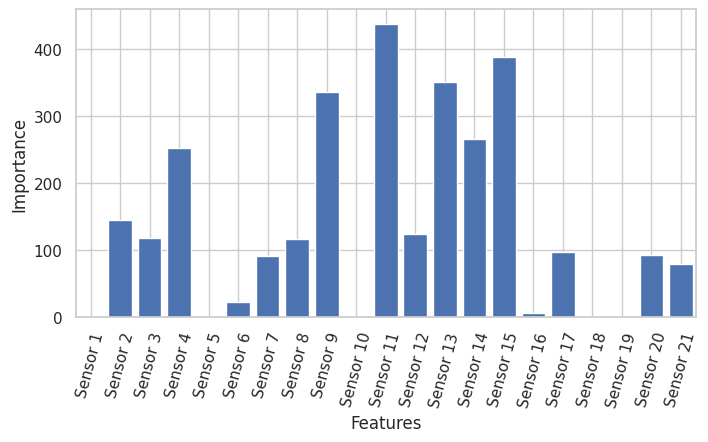

In [ ]:
import matplotlib.pyplot as plt
features = {
    "Sensor 1": "Total temperature at fan inlet (°R)",
    "Sensor 2": "Total temperature at LPC outlet (°R)",
    "Sensor 3": "Total temperature at HPC outlet (°R)",
    "Sensor 4": "Total temperature at LPT outlet (°R)",
    "Sensor 5": "Pressure at fan inlet (psia)",
    "Sensor 6": "Total pressure in bypass-duct (psia)",
    "Sensor 7": "Total pressure at HPC outlet (psia)",
    "Sensor 8": "Physical fan speed",
    "Sensor 9": "Physical core speed",
    "Sensor 10": "Engine pressure ratio",
    "Sensor 11": "Static pressure at HPC outlet (psia)",
    "Sensor 12": "Ratio of fuel flow to Ps30 (pps/psi)",
    "Sensor 13": "Corrected fan speed (rpm)",
    "Sensor 14": "Corrected core speed (rpm)",
    "Sensor 15": "Bypass ratio",
    "Sensor 16": "Burner fuel-air ratio",
    "Sensor 17": "Bleed enthalpy",
    "Sensor 18": "Demanded fan speed (rpm)",
    "Sensor 19": "Demanded corrected fan speed (rpm)",
    "Sensor 20": "HPT coolant bleed (lbm/s)",
    "Sensor 21": "LPT coolant bleed (lbm/s)"
}

# Get feature importance
importances = lgb_reg.feature_importances_
feature_names = X_train1.columns

# Plot feature importance
plt.figure(figsize=(8,4))
plt.bar(feature_names, importances)
plt.xlabel("Features")
plt.ylabel("Importance")
plt.xticks(np.arange(5,len(list(features.keys()))+5), list(features.keys()), rotation=75)
plt.xlim(4.5,25.5)
# plt.title("Feature Importance")
plt.show()


# SHAP for Gradient Boosting

In [44]:
# SHAP Analysis
import shap
explainer = shap.Explainer(lgb_reg, X_train1)
shap_values = explainer(X_test1[:200], check_additivity=False)

/tmp/ipython-input-2423084846.py:37: UserWarning: You passed a edgecolor/edgecolors ('none') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(


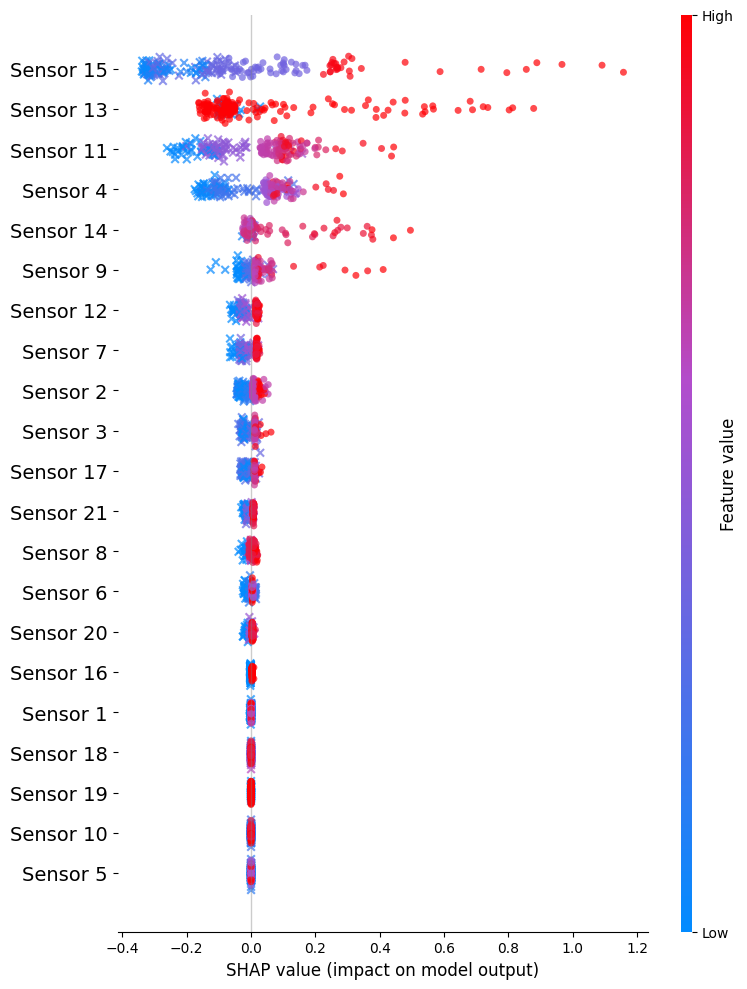

In [46]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm
from matplotlib.colors import ListedColormap

# --- 1. Data Preparation ---
X_data = X_test1[:200]
# Use the actual SHAP values (not the object) for manual plotting
shap_values_matrix = shap_values.values[:200]
feature_names_list = list(features.keys())

# --- 2. Setup Figure ---
fig, ax = plt.subplots(figsize=(8, 10))

# Calculate global feature importance for ranking (mean absolute SHAP)
mean_abs_shap = np.abs(shap_values_matrix).mean(0)
feature_order = np.argsort(mean_abs_shap)

for i, feature_idx in enumerate(feature_order):
    shaps = shap_values_matrix[:, feature_idx]
    f_values = X_data.iloc[:, feature_idx].values

    # Calculate threshold based on MEAN (consistent with dependence plots)
    threshold = f_values.mean()

    # Define masks for markers
    low_mask = (f_values <= threshold)
    high_mask = (f_values > threshold)

    # Normalise for consistent colour mapping (MIN/MAX)
    norm = plt.Normalize(f_values.min(), f_values.max())

    # Add jitter to mimic the 'beeswarm' density
    jitter = np.random.normal(0, 0.12, size=len(shaps))

    # Plot 'Low' values with 'x' (Consistent with your Dependence Plot code)
    ax.scatter(
        shaps[low_mask], i + jitter[low_mask],
        c=f_values[low_mask], cmap='shap_red_blue', norm=norm,
        marker='x', s=30, alpha=0.7, edgecolors='none'
    )

    # Plot 'High' values with 'o' (Consistent with your Dependence Plot code)
    ax.scatter(
        shaps[high_mask], i + jitter[high_mask],
        c=f_values[high_mask], cmap='shap_red_blue', norm=norm,
        marker='o', s=25, alpha=0.7, edgecolors='none'
    )

# --- 4. Aesthetics and Colorbar (Updated for Formatting) ---

# Generate the cleaned labels by removing the hyphen/dash
cleaned_labels = [feature_names_list[idx].replace('-', '').strip() for idx in feature_order]

ax.set_yticks(range(len(feature_order)))

# Use the cleaned labels and increase the fontsize to your preference (e.g., 14)
ax.set_yticklabels(cleaned_labels, fontsize=14)

ax.axvline(0, color='gray', lw=1, alpha=0.4)
ax.set_xlabel("SHAP value (impact on model output)", fontsize=12)

# Colorbar configuration
sm = plt.cm.ScalarMappable(cmap='shap_red_blue', norm=plt.Normalize(0, 1))
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, ticks=[0, 1], aspect=80, pad=0.05)
cbar.set_ticklabels(['Low', 'High'])
cbar.set_label('Feature value', fontsize=12, labelpad=-10)
cbar.outline.set_visible(False)

# Remove spines to match the original SHAP aesthetic
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

plt.tight_layout()
plt.show()

In [45]:
import numpy as np
import pandas as pd
from scipy.stats import spearmanr
# We use .mean() for arithmetic mean, not gmean
from numpy import mean as arithmetic_mean

# --- 1. Prepare Prognostic Scores ---
# Calculate Arithmetic Mean (This is robust to zeros)
results['Arithmetic_Mean'] = results[['Monotonicity', 'Trendability', 'Prognosability']].apply(arithmetic_mean, axis=1)

# Set 'Feature' as the index for easy lookup
prognostic_scores = results.set_index('Feature')['Arithmetic_Mean']

print("--- 1. Prognostic Scores (Arithmetic Mean) ---")
print(prognostic_scores.head())

# --- 2. Prepare SHAP Scores ---
shap_values_raw = shap_values.values

# Calculate mean absolute SHAP values for all 21 features
mean_abs_shap = np.abs(shap_values_raw).mean(axis=0)

# Manually create the 21 string names for the index
sensor_names_21 = [f'Sensor {i}' for i in range(1, 22)]

# Create the Series using the correct string names
shap_scores = pd.Series(mean_abs_shap, index=sensor_names_21)

print("\n--- 2. SHAP Scores (All 21 Sensors) ---")
print(shap_scores.head())

# --- 3. Align Both Lists to the 15 Model Features ---
# This list is from your manuscript [cite: 118-119]
model_feature_names = [
    'Sensor 2', 'Sensor 3', 'Sensor 4', 'Sensor 6',
    'Sensor 7', 'Sensor 8', 'Sensor 9', 'Sensor 11',
    'Sensor 12', 'Sensor 13', 'Sensor 14', 'Sensor 15',
    'Sensor 17', 'Sensor 20', 'Sensor 21'
]

# Filter prognostic scores to only these 15
aligned_prognostic = prognostic_scores.loc[model_feature_names]

# Filter SHAP scores to only these 15
aligned_shap = shap_scores.loc[model_feature_names]

print(f"\n--- 3. Aligned for {len(model_feature_names)} Model Features ---")
print("Prognostic:\n", aligned_prognostic)
print("\nSHAP:\n", aligned_shap)


# --- 4. Calculate Spearman Rank Correlation ---
correlation, p_value = spearmanr(aligned_prognostic, aligned_shap)

print("\n" + "="*40)
print("   SPEARMAN CORRELATION RESULTS   ")
print("="*40)
print(f"Spearman Rank Correlation (rho): {correlation:.4f}")
print(f"P-value: {p_value:.4f}")
print("\nThese are the REAL numbers for Reviewer #2.")

--- 1. Prognostic Scores (Arithmetic Mean) ---
Feature
Sensor 2    0.209795
Sensor 3    0.207015
Sensor 4    0.287744
Sensor 6    0.082916
Sensor 7    0.149042
Name: Arithmetic_Mean, dtype: float64

--- 2. SHAP Scores (All 21 Sensors) ---
Sensor 1    0.000579
Sensor 2    0.019472
Sensor 3    0.015609
Sensor 4    0.093194
Sensor 5    0.000000
dtype: float64

--- 3. Aligned for 15 Model Features ---
Prognostic:
 Feature
Sensor 2     0.209795
Sensor 3     0.207015
Sensor 4     0.287744
Sensor 6     0.082916
Sensor 7     0.149042
Sensor 8     0.158648
Sensor 9     0.196119
Sensor 11    0.322797
Sensor 12    0.164092
Sensor 13    0.159440
Sensor 14    0.161470
Sensor 15    0.282767
Sensor 17    0.221373
Sensor 20    0.131203
Sensor 21    0.130352
Name: Arithmetic_Mean, dtype: float64

SHAP:
 Sensor 2     0.019472
Sensor 3     0.015609
Sensor 4     0.093194
Sensor 6     0.006917
Sensor 7     0.021940
Sensor 8     0.007409
Sensor 9     0.030959
Sensor 11    0.119866
Sensor 12    0.023126
Sens

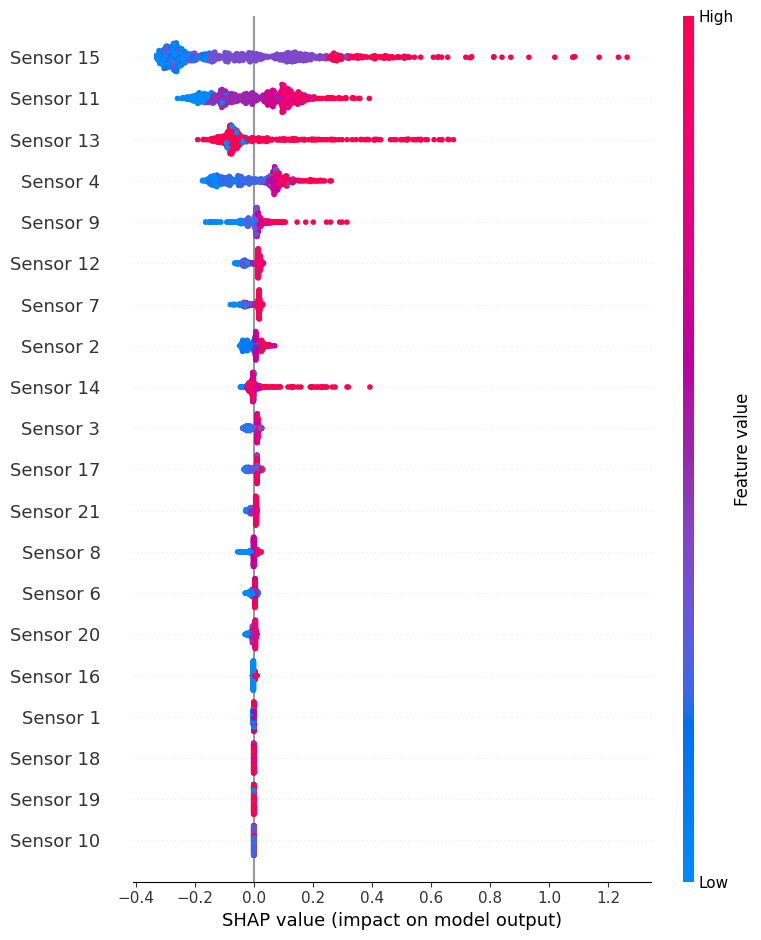

In [ ]:
x_val = df_test.iloc[:,5:-2]
shap_values = explainer(x_val[:712])
# 1. Summary Plot
features = {
    "Sensor 1": "Total temperature at fan inlet (°R)",
    "Sensor 2": "Total temperature at LPC outlet (°R)",
    "Sensor 3": "Total temperature at HPC outlet (°R)",
    "Sensor 4": "Total temperature at LPT outlet (°R)",
    "Sensor 5": "Pressure at fan inlet (psia)",
    "Sensor 6": "Total pressure in bypass-duct (psia)",
    "Sensor 7": "Total pressure at HPC outlet (psia)",
    "Sensor 8": "Physical fan speed",
    "Sensor 9": "Physical core speed",
    "Sensor 10": "Engine pressure ratio",
    "Sensor 11": "Static pressure at HPC outlet (psia)",
    "Sensor 12": "Ratio of fuel flow to Ps30 (pps/psi)",
    "Sensor 13": "Corrected fan speed (rpm)",
    "Sensor 14": "Corrected core speed (rpm)",
    "Sensor 15": "Bypass ratio",
    "Sensor 16": "Burner fuel-air ratio",
    "Sensor 17": "Bleed enthalpy",
    "Sensor 18": "Demanded fan speed (rpm)",
    "Sensor 19": "Demanded corrected fan speed (rpm)",
    "Sensor 20": "HPT coolant bleed (lbm/s)",
    "Sensor 21": "LPT coolant bleed (lbm/s)"
}
shap.summary_plot(shap_values, x_val[:712], feature_names=list(features.keys()))


In [ ]:
x_val.columns = list(features.keys())

Saving high-resolution force plot (no grid)...


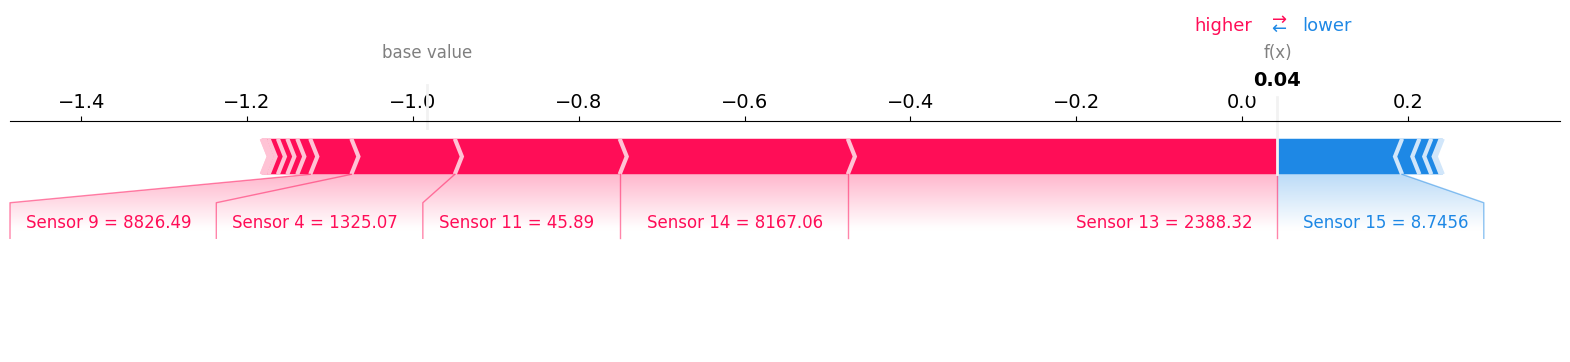

In [ ]:
import matplotlib.pyplot as plt
import shap

# --- Your original setup ---
idx = 257
base_val = shap_values.base_values[idx]
shap_vals = shap_values.values[idx]
features_vals = x_val.iloc[idx] # Assuming x_val corresponds to X_test
feature_names_list = list(features.keys())

# --- 1. SET MATPLOTLIB FONT SIZE ---
original_fontsize = plt.rcParams['font.size']
plt.rcParams['font.size'] = 12

# --- 2. Generate the Matplotlib Figure Object ---
force_plot_fig = shap.force_plot(
    base_value=base_val,
    shap_values=shap_vals,
    features=features_vals,
    feature_names=feature_names_list,
    matplotlib=True,
    show=False
)

# --- 3. THIS IS THE FIX: Remove Gridlines ---
# --- 2. Get Axes, Remove Grid, Set Ticks ---
ax = force_plot_fig.gca()
ax.grid(False)
new_font_size = 14  # Set your desired font size
ax.tick_params(axis='x', labelsize=new_font_size)

# --- END OF FIX ---

# --- 4. Save the Figure for Publication ---
print("Saving high-resolution force plot (no grid)...")
force_plot_fig.savefig(
    "figure_17_force_plot.png",
    dpi=300,
    bbox_inches='tight'
)

# --- 5. RESET FONT SIZE ---
plt.rcParams['font.size'] = original_fontsize

# --- 6. (Optional) Show the plot in the notebook ---
plt.show()

Saving high-resolution force plot (no grid)...


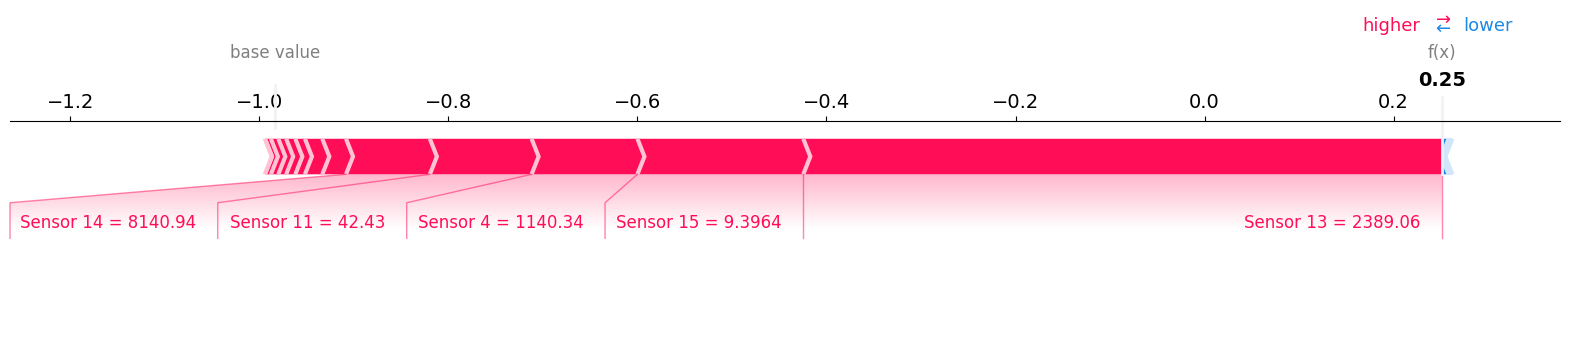

In [ ]:
import matplotlib.pyplot as plt
import shap

# --- Your original setup ---
idx = 711
base_val = shap_values.base_values[idx]
shap_vals = shap_values.values[idx]
features_vals = x_val.iloc[idx] # Assuming x_val corresponds to X_test
feature_names_list = list(features.keys())

# --- 1. SET MATPLOTLIB FONT SIZE ---
original_fontsize = plt.rcParams['font.size']
plt.rcParams['font.size'] = 12

# --- 2. Generate the Matplotlib Figure Object ---
force_plot_fig = shap.force_plot(
    base_value=base_val,
    shap_values=shap_vals,
    features=features_vals,
    feature_names=feature_names_list,
    matplotlib=True,
    show=False
)

# --- 3. THIS IS THE FIX: Remove Gridlines ---
# --- 2. Get Axes, Remove Grid, Set Ticks ---
ax = force_plot_fig.gca()
ax.grid(False)
new_font_size = 14  # Set your desired font size
ax.tick_params(axis='x', labelsize=new_font_size)

# --- END OF FIX ---

# --- 4. Save the Figure for Publication ---
print("Saving high-resolution force plot (no grid)...")
force_plot_fig.savefig(
    "figure_17_force_plot.png",
    dpi=300,
    bbox_inches='tight'
)

# --- 5. RESET FONT SIZE ---
plt.rcParams['font.size'] = original_fontsize

# --- 6. (Optional) Show the plot in the notebook ---
plt.show()

In [ ]:
import pandas as pd
import numpy as np

# --- Assumptions & Placeholder Setup ---
# This setup creates dummy data that mimics the structure of your objects
# (shap_values, x_val, features) so the code can run.
# In your environment, you would use your actual, pre-calculated objects.

# Define feature names based on your snippet
feature_names = [f'Sensor {i}' for i in range(1, 22)]
num_features = len(feature_names)

# The instance index from your code
instance_index = [257, 711]

# --- Code to Generate the Table ---

def get_force_plot_table(shap_values_obj, feature_data, instance_idx):
    """
    Extracts the data for a single SHAP force plot and returns it as a
    sorted pandas DataFrame.

    Args:
        shap_values_obj: The SHAP values object containing .values and .base_values.
        feature_data (pd.DataFrame): The DataFrame with the raw feature values.
        instance_idx (int): The index of the specific instance to analyze.

    Returns:
        pd.DataFrame: A sorted table of features, their values, and SHAP contributions.
    """
    df = pd.DataFrame({
        'Feature Name': feature_data.columns
    })
    for i in range(len(instance_idx)):
      # Extract the SHAP values for the specific instance
      instance_shap_values = shap_values_obj.values[instance_idx[i]]

      # Extract the raw feature values for the same instance
      # NOTE: Correcting the index to match the SHAP values index for consistency.
      instance_feature_values = feature_data.iloc[instance_idx[i]]

      # Create the DataFrame

      df[f'Feature Value {i}'] = instance_feature_values.values
      df[f'SHAP Value {i}'] = instance_shap_values

    return df

# Generate and display the table for your chosen instance
force_plot_df = get_force_plot_table(shap_values, x_val, instance_index)

print(f"--- SHAP Force Plot Data for Instance {instance_index} ---")
print(f"Base Value (Average Prediction): {shap_values.base_values[instance_index[0]]:.4f}")
print(f"Base Value (Average Prediction): {shap_values.base_values[instance_index[1]]:.4f}")
final_prediction0 = shap_values.base_values[instance_index[0]] + force_plot_df['SHAP Value 0'].sum()
final_prediction1 = shap_values.base_values[instance_index[1]] + force_plot_df['SHAP Value 1'].sum()
print(f"Final Prediction: {final_prediction0:.4f}")
print(f"Final Prediction: {final_prediction1:.4f}")
print("-" * 50)
print(force_plot_df.to_string())

--- SHAP Force Plot Data for Instance [257, 711] ---
Base Value (Average Prediction): -0.9831
Base Value (Average Prediction): -0.9831
Final Prediction: 0.0427
Final Prediction: 0.2511
--------------------------------------------------
   Feature Name  Feature Value 0  SHAP Value 0  Feature Value 1  SHAP Value 1
0      Sensor 1         489.0500      0.000194         445.0000     -0.000410
1      Sensor 2         605.4200      0.011985         550.8100      0.009693
2      Sensor 3        1515.0000      0.011417        1358.9500      0.000121
3      Sensor 4        1325.0700      0.124762        1140.3400      0.111977
4      Sensor 5          10.5200      0.000000           3.9100      0.000000
5      Sensor 6          15.5000      0.004768           5.7200     -0.002830
6      Sensor 7         163.3900     -0.014380         418.5500      0.025055
7      Sensor 8        2319.1100      0.015656        2212.9000     -0.007135
8      Sensor 9        8826.4900      0.049591        8391.570

# Per Engine Prognostic Metric Plots

In [ ]:
train_df = s_nonflat.copy()
train_df.insert(0, 'cycles', df_train.iloc[:,1])
train_df.insert(0, 'unit_nr', df_train.iloc[:,0])
sensors_columns = [f'Sensor {i}' for i in range(1, 22)]
# Remove constant sensors identified from the notebook for cleaner plots
sensors_columns.remove('Sensor 1') # remove manually if not caught by std()==0
sensors_columns.remove('Sensor 5')
sensors_columns.remove('Sensor 18')
sensors_columns.remove('Sensor 19')

columns = ['unit_nr', 'cycles'] + sensors_columns
train_df.columns = columns
train_df

,unit_nr,cycles,Sensor 2,Sensor 3,Sensor 4,Sensor 6,Sensor 7,Sensor 8,Sensor 9,Sensor 10,Sensor 11,Sensor 12,Sensor 13,Sensor 14,Sensor 15,Sensor 16,Sensor 17,Sensor 20,Sensor 21
0,1,1,-1.090341,-1.443080,0.770031,-0.174690,-0.412694,-1.400815,-0.835488,-0.201638,0.163636,-0.097690,-1.395816,-1.531618,0.361688,-4.000000,-0.167404,0.890407,1.352348
1,1,2,0.450794,-0.220659,-0.264837,-1.184755,0.274151,-1.339755,-1.328420,-0.158300,0.214488,0.380158,-1.213319,-1.040095,0.062511,-4.000000,-0.757098,1.634765,1.315594
2,1,3,1.242458,-1.122073,-0.421669,-1.856228,-0.634449,-1.165851,-0.998547,0.089081,-0.534250,1.024452,-1.024524,-1.042345,-0.459720,-4.000000,1.277815,1.631373,-1.720463
3,1,4,-0.450245,-0.076871,-0.186270,-1.184755,0.388018,-1.306391,-1.328420,-0.158300,-0.790603,-0.500487,-1.367973,-1.261000,-0.593229,-4.000000,-1.466987,-0.033181,-1.845375
4,1,5,0.572265,-0.942156,-0.351169,0.535646,0.839728,-1.203979,-1.579438,0.089081,0.425103,0.762651,-1.132672,-1.321497,-0.408803,-4.000000,1.277815,1.185251,0.451156
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53754,260,312,2.645665,1.731395,2.103295,0.713320,0.819669,7.110729,7.118176,-1.845791,1.142373,1.655424,6.682108,6.858276,1.817660,1.915154,2.465893,0.697438,1.929249
53755,260,313,1.889726,2.125800,1.521453,1.429549,2.777619,2.238917,7.146739,0.019253,2.345867,0.422501,2.643668,6.881016,2.461214,-4.000000,2.887767,2.960199,1.985342
53756,260,314,1.717179,2.567172,1.116121,2.927519,0.705711,7.451130,7.009807,0.089081,1.624294,2.420724,7.266833,7.115940,3.511765,-4.000000,2.051387,0.649904,0.123222
53757,260,315,2.722469,1.944091,2.346940,2.927519,1.375792,7.413002,6.889231,0.089081,2.487711,0.588116,7.338932,7.209501,3.234039,-4.000000,2.824959,1.899046,2.804122


In [ ]:
!pip install adjustText

Generating Boxplots for Prognostic Metrics...


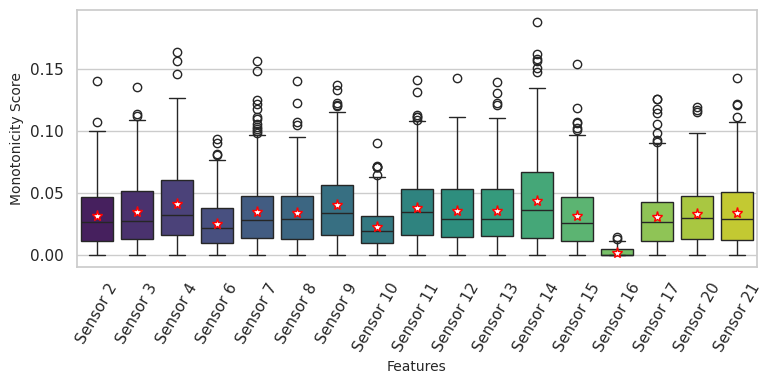

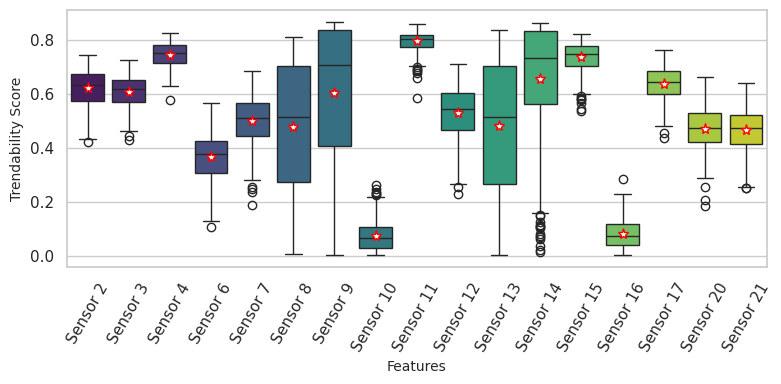

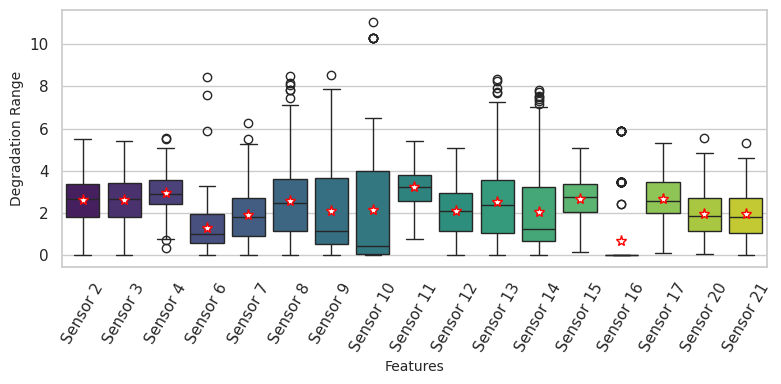


Generating FINAL Scatterplot Matrix (300 DPI, Legend Moved)...


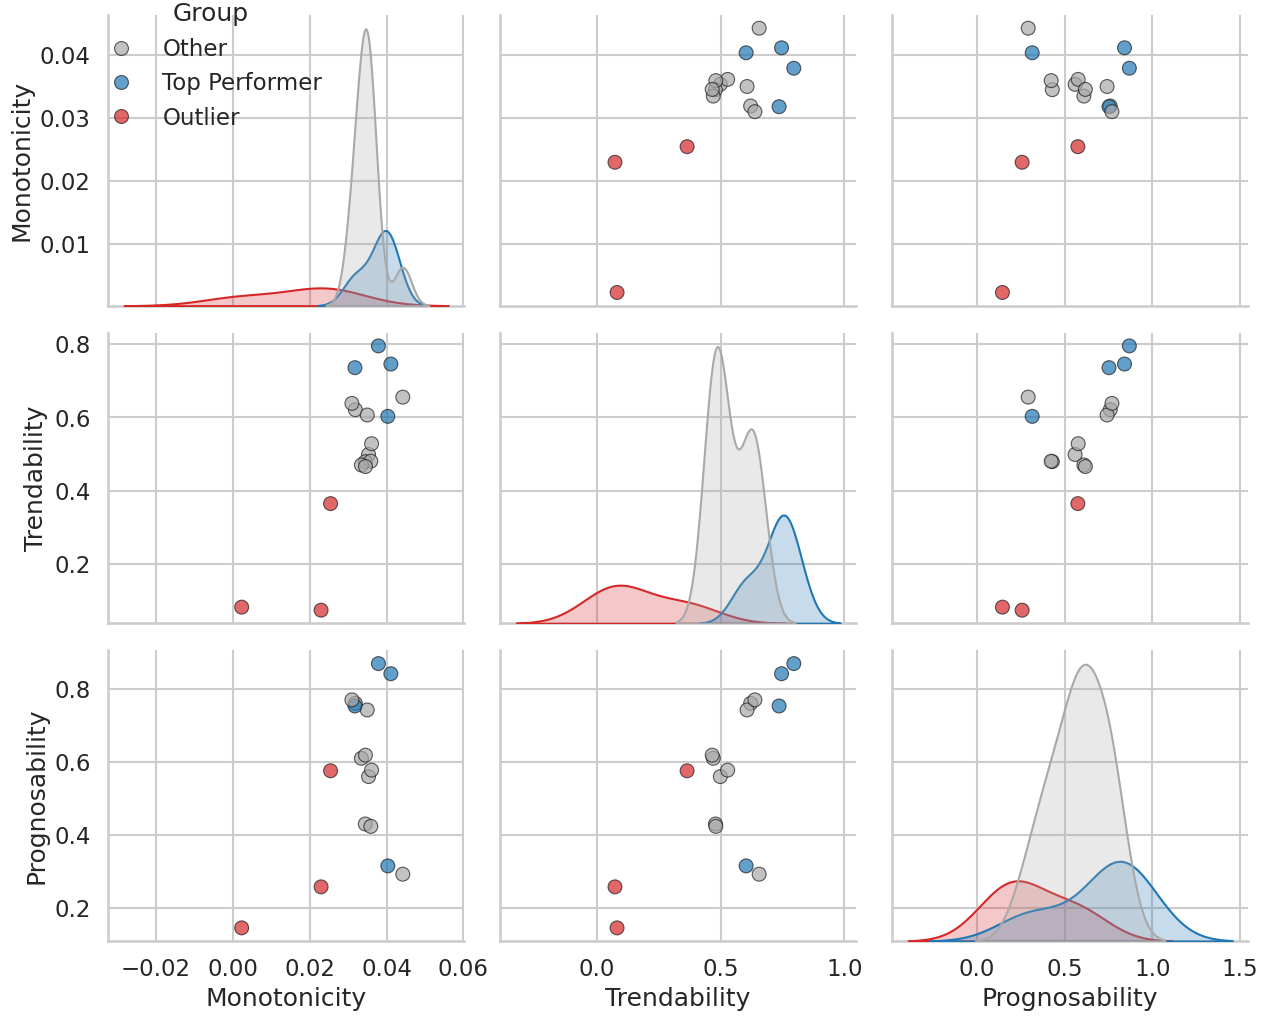

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from adjustText import adjust_text

# --- (Your metric calculation functions go here) ---
# ... (all functions) ...
def calculate_monotonicity_per_engine(df, sensor_cols):
    """Calculates monotonicity for each sensor for each engine unit."""
    monotonicity_scores = {sensor: [] for sensor in sensor_cols}
    for unit in df['unit_nr'].unique():
        unit_df = df[df['unit_nr'] == unit]
        for sensor in sensor_cols:
            if unit_df[sensor].std() < 1e-6:  # Skip constant sensors
                monotonicity_scores[sensor].append(np.nan)
                continue
            diff = np.diff(unit_df[sensor])
            score = np.abs(np.mean(np.sign(diff)))
            monotonicity_scores[sensor].append(score)
    return monotonicity_scores

def calculate_trendability_per_engine(df, sensor_cols):
    """Calculates trendability for each sensor for each engine unit."""
    trendability_scores = {sensor: [] for sensor in sensor_cols}
    for unit in df['unit_nr'].unique():
        unit_df = df[df['unit_nr'] == unit]
        time = unit_df['cycles']
        for sensor in sensor_cols:
            if unit_df[sensor].std() < 1e-6: # Skip constant sensors
                trendability_scores[sensor].append(np.nan)
                continue
            corr, _ = pearsonr(time, unit_df[sensor])
            trendability_scores[sensor].append(np.abs(corr))
    return trendability_scores
# ... (and calculate_prognosability_per_engine) ...
def calculate_prognosability_per_engine(df, sensor_cols):
    """Calculates prognosability for each sensor across all engines."""
    prognosability_scores = {sensor: [] for sensor in sensor_cols}
    initial_values = df.groupby('unit_nr').first()
    final_values = df.groupby('unit_nr').last()

    for sensor in sensor_cols:
        if final_values[sensor].std() < 1e-6:
             prognosability_scores[sensor] = [np.nan] * df['unit_nr'].nunique()
             continue
        x0 = initial_values[sensor]
        xf = final_values[sensor]
        degradation_range = np.abs(xf - x0)
        prognosability_scores[sensor] = list(degradation_range)

    return prognosability_scores

# --- (Your data preparation code goes here) ---
# ...
sensors_to_plot = [f'Sensor {i}' for i in range(1, 22)]
sensors_to_plot.remove('Sensor 1') # remove manually if not caught by std()==0
sensors_to_plot.remove('Sensor 5')
sensors_to_plot.remove('Sensor 18')
sensors_to_plot.remove('Sensor 19')


mono_scores_per_engine = calculate_monotonicity_per_engine(train_df, sensors_to_plot)
trend_scores_per_engine = calculate_trendability_per_engine(train_df, sensors_to_plot)
prog_scores_per_engine = calculate_prognosability_per_engine(train_df, sensors_to_plot)

mono_df = pd.DataFrame(mono_scores_per_engine)
trend_df = pd.DataFrame(trend_scores_per_engine)
prog_df = pd.DataFrame(prog_scores_per_engine)
# ...
def calculate_prognosability_single_value(df, sensor_cols):
    scores = {}
    initial_values = df.groupby('unit_nr').first()
    final_values = df.groupby('unit_nr').last()
    for sensor in sensor_cols:
        if final_values[sensor].std() < 1e-6:
            scores[sensor] = np.nan
            continue
        x0 = initial_values[sensor]
        xf = final_values[sensor]
        std_xf = np.std(xf)
        mean_abs_diff = np.mean(np.abs(xf - x0))
        if mean_abs_diff == 0:
             scores[sensor] = 0
        else:
            scores[sensor] = np.exp(-std_xf / mean_abs_diff)
    return pd.Series(scores, name='Prognosability')
# ...

mean_mono = mono_df.mean().rename('Monotonicity')
mean_trend = trend_df.mean().rename('Trendability')
prog_series = calculate_prognosability_single_value(train_df, sensors_to_plot)
metrics_corr_df = pd.concat([mean_mono, mean_trend, prog_series], axis=1).dropna()

# --- Plotting Section (MODIFIED) ---

# Set plot style
sns.set(style="whitegrid")

# Define the mean marker style for the boxplots
mean_marker_props = {
    'marker': '*',
    'markerfacecolor': 'white',
    'markeredgecolor': 'red',
    'markersize': 8
}

## 1. Boxplots for Prognostic Metrics (MODIFIED)

print("Generating Boxplots for Prognostic Metrics...")

# Figure for Monotonicity (New Fig 5)
plt.figure(figsize=(8, 4))
sns.boxplot(
    data=mono_df,
    palette="viridis",  # <-- CHANGED: Consistent palette
    showmeans=True,       # <-- ADDED: Show mean
    meanprops=mean_marker_props # <-- ADDED: Style mean as star
)
# plt.title("Figure 5 (New): Monotonicity Scores (Median line, Mean star)", fontsize=12)
plt.xlabel('Features', fontsize=10)
plt.ylabel('Monotonicity Score', fontsize=10)
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()

# Figure for Trendability (New Fig 6)
plt.figure(figsize=(8, 4))
sns.boxplot(
    data=trend_df,
    palette="viridis",  # <-- CHANGED: Consistent palette
    showmeans=True,       # <-- ADDED: Show mean
    meanprops=mean_marker_props # <-- ADDED: Style mean as star
)
# plt.title("Figure 6 (New): Trendability Scores (Median line, Mean star)", fontsize=12)
plt.xlabel('Features', fontsize=10)
plt.ylabel('Trendability Score', fontsize=10)
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()

# Figure for Prognosability (Degradation Range) (New Fig 7)
plt.figure(figsize=(8, 4))
sns.boxplot(
    data=prog_df,
    palette="viridis",  # <-- CHANGED: Consistent palette
    showmeans=True,       # <-- ADDED: Show mean
    meanprops=mean_marker_props # <-- ADDED: Style mean as star
)
# plt.title("Figure 7 (New): Degradation Range (Median line, Mean star)", fontsize=12)
plt.xlabel('Features', fontsize=10)
plt.ylabel('Degradation Range', fontsize=10)
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()

## 2. Scatterplot Matrix for Correlating Metrics
print("\nGenerating FINAL Scatterplot Matrix (300 DPI, Legend Moved)...")

# Temporarily increase font size for pairplot
sns.set_context("talk")

# 1. Define groups
outliers = ['Sensor 6', 'Sensor 10', 'Sensor 16']
top_performers = ['Sensor 4', 'Sensor 9', 'Sensor 11', 'Sensor 15']

# 2. Create 'Group' column
def assign_group(sensor_name):
    if sensor_name in outliers:
        return 'Outlier'
    elif sensor_name in top_performers:
        return 'Top Performer'
    else:
        return 'Other'
metrics_corr_df['Group'] = metrics_corr_df.index.map(assign_group)

# 3. Define palette
palette = {
    "Top Performer": "#1f77b4",
    "Outlier": "#d62728",
    "Other": "darkgray"
}

# 4. Generate the pairplot
g = sns.pairplot(
    metrics_corr_df,
    height=3.5,
    diag_kind='kde',
    hue='Group',
    palette=palette,
    diag_kws={'fill': True},
    plot_kws={'s': 100, 'edgecolor': 'k', 'alpha': 0.7}
)

# 5. **THIS IS THE FIX: Move the legend**
# We move the legend to the top-left corner of the *figure*
# Bbox (0.01, 0.99) places the anchor point at 1% from left, 99% from bottom
# loc='upper left' sets the anchor point to the legend's upper-left corner
plt.setp(
    g.legend,
    bbox_to_anchor=(0.06, 0.99),
    loc='upper left'
)
# **--- END OF FIX ---**

# g.fig.suptitle("Figure 8: Prognostic Metric Correlations", y=1.03, fontsize=16)
plt.tight_layout()
plt.savefig("figure_8_pairplot.png", dpi=300, bbox_inches='tight')
plt.show()

# Reset font scale to default after plotting
sns.set_context("notebook")

# RMSE Delta

In [50]:
import numpy as np

# 1. Setup parameters
n_iterations = 1000
delta_rmse_samples = []
rf_preds = rf_model.predict(X_test1)
gb_preds = lgb_reg.predict(X_test1)

# Convert y_test1 to a numpy array for consistent positional indexing
y_test1_np = y_test1.values

# 2. Perform Paired Bootstrap
# Ensure y_test, rf_preds, and gb_preds are numpy arrays
for _ in range(n_iterations):
    # Sample indices with replacement (Bootstrap)
    indices = np.random.choice(len(y_test1_np), size=len(y_test1_np), replace=True)

    # Calculate RMSE for this specific bootstrap sample
    rmse_rf = np.sqrt(np.mean((y_test1_np[indices] - rf_preds[indices])**2))
    rmse_gb = np.sqrt(np.mean((y_test1_np[indices] - gb_preds[indices])**2))

    # Calculate the Delta (Difference)
    delta_rmse_samples.append(rmse_rf - rmse_gb)

# 3. Compute the 95% Confidence Interval for the Difference
ci_lower = np.percentile(delta_rmse_samples, 2.5)
ci_upper = np.percentile(delta_rmse_samples, 97.5)

print(f"Actual 95% CI for the difference in RMSE: [{ci_lower:.4f}, {ci_upper:.4f}]")

Actual 95% CI for the difference in RMSE: [0.0054, 0.0087]
